# Baroclinic Storm Severity Regimes in a Perturbed-Physics OpenIFS Ensemble

**A data-driven analysis of how background atmospheric conditions shape extratropical cyclone severity**

---

## Overview

This notebook analyzes a large ensemble of OpenIFS (Open Integrated Forecasting System) idealised baroclinic-wave simulations. Each ensemble member was initialised with a different combination of seven background atmospheric parameters — jet strength, jet height/shape, static stability, initial humidity, lapse rate, sea-surface roughness (Charnock parameter), and a categorical zonal-wavenumber parameter — and then run forward to let baroclinic instability grow, mature, and (where it succeeds) spin up an extratropical storm. Every storm that formed was tracked, and each track was summarised by a set of severity metrics: peak relative vorticity, minimum sea-level pressure, peak 10 m wind speed, vorticity deepening rate, a Storm Severity Index (SSI), and windstorm footprint metrics at two wind-speed thresholds.

This notebook asks three linked questions of that dataset:

1. **Structure** — Do the storms produced by this ensemble fall into a small number of natural *severity regimes*, or does severity vary continuously and unimodally?
2. **Predictability** — How much of a storm's eventual severity is already determined by the background atmospheric state it grew out of, versus the storm's own chaotic evolution?
3. **Attribution** — Which background parameters, if any, distinguish the most severe or most anomalous storms from the rest of the population?

The workflow moves from raw XML/CSV ingestion, through exploratory data analysis, principal component analysis (PCA), Gaussian-mixture clustering, a small classification network, and finally two feedforward regression networks — a single model and a 5-member deep ensemble — used to quantify both predictive accuracy and predictive uncertainty.

## Data

- **Background parameters** — `openifs_submission.xml`: one `<workunit>` element per ensemble member, storing the 7 perturbed background parameters (`n`, `b`, `u0`, `Tv0`, `RH0`, `lapse_rate`, `charnock`).
- **Storm-tracked features** — `ExtractedFeatures/*.csv`: one file per `(unique_member_id, track_index)` pair, storing up to 3 tracked storms per ensemble member together with their peak-intensity and impact metrics.

> **Note on citations.** Full dataset provenance, licensing, and the software versions used are collected in [§18 Data & Software Citations](#18-data--software-citations) at the end of this notebook.

## Reproducing this notebook

Every figure produced below is saved automatically to a local `figures/` directory (created in [§1](#1-setup-and-imports)) as the notebook runs — both static PNGs and, for the two interactive Plotly views, standalone HTML files. This makes the full figure set reusable outside Jupyter (e.g. in a paper, a GitHub README, or a slide deck) without needing to re-execute the notebook.

## Contents

1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading](#2-data-loading)
3. [Building the Tidy Analysis Table](#3-building-the-tidy-analysis-table)
4. [Data Validation & Sanity Checks](#4-data-validation--sanity-checks)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Selecting One Storm per Ensemble Run](#6-selecting-one-storm-per-ensemble-run)
7. [Dimensionality Reduction with PCA](#7-dimensionality-reduction-with-pca)
8. [Clustering Storms into Severity Regimes](#8-clustering-storms-into-severity-regimes)
9. [Naming the Severity Regimes](#9-naming-the-severity-regimes)
10. [Classifying Regimes from Background Parameters](#10-classifying-regimes-from-background-parameters-neural-network)
11. [Visualizing the Severity Regimes](#11-visualizing-the-severity-regimes)
12. [Predicting Storm Severity from Background Parameters](#12-predicting-storm-severity-from-background-parameters-regression-mlp)
13. [Interactive 3D Visualization of Severity Regimes](#13-interactive-3d-visualization-of-severity-regimes)
14. [Model Uncertainty via Deep Ensembles](#14-model-uncertainty-via-deep-ensembles)
15. [Investigating the Anomalous-Footprint Regime](#15-investigating-the-anomalous-footprint-regime)
16. [Severity Regimes in Full 3D PCA Space](#16-severity-regimes-in-full-3d-pca-space)
17. [Summary and Key Findings](#17-summary-and-key-findings)
18. [Data & Software Citations](#18-data--software-citations)

## 1. Setup and Imports

Standard scientific-Python stack (NumPy, pandas, Matplotlib/Seaborn for static plots, Plotly for the interactive 3D views), plus PyTorch and scikit-learn for the modelling stages later on. A fixed `RANDOM_STATE` is used everywhere a stochastic step occurs (train/test splits, KMeans/GMM initialisation, network weight initialisation) so results are reproducible run-to-run. `FIGURES_DIR` is where every plot produced later in the notebook is written to disk.

In [3]:
import re
import warnings
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)

# point these at your local copies of the two FairData.fi repositories
XML_PATH = Path("openifs_submission.xml")
FEATURES_DIR = Path("ExtractedFeatures")

print(f"XML exists: {XML_PATH.exists()}")
print(f"Features dir exists: {FEATURES_DIR.exists()}")

# figures/ holds every plot this notebook produces, saved as it runs, so the
# full figure set can be version-controlled and reused (paper, README, repo)
# without re-executing the notebook.
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

XML exists: True
Features dir exists: True


## 2. Data Loading

The raw dataset is split across two files/directories that have to be parsed and joined separately: an XML file describing the background state of every ensemble member, and a directory of per-storm CSV files describing what each member's storm(s) actually did.

### 2.1 Parsing background parameters from the XML submission file

Each `<workunit>` corresponds to one ensemble member (one full OpenIFS simulation) and stores the 7 background parameters that were perturbed to generate it. Two parsing details matter for correctness downstream: `zrh0` is already stored as a **fraction** (0–0.8) in the raw XML, not a percentage, so it is left unscaled; and `zn` is a categorical zonal-wavenumber parameter (integer 1–6) that is stored as a float in the XML, so it is rounded and cast to a nullable integer after parsing.

In [5]:
# XML param tag -> tidy column name (see dataset reference)
PARAM_TAGS = {
    "zn": "n", "zb": "b", "zu0": "u0", "zt0": "Tv0",
    "zrh0": "RH0", "zgamma": "lapse_rate", "zchar": "charnock",
}
PARAM_COLS = list(PARAM_TAGS.values())


def parse_workunits(xml_path: Path) -> pd.DataFrame:
    """XML -> one row per unique_member_id with the 7 background params."""
    root = ET.parse(xml_path).getroot()
    records = []
    for wu in root.iter("workunit"):
        uid_el = wu.find(".//unique_member_id")
        if uid_el is None or not uid_el.text:
            continue
        row = {"unique_member_id": uid_el.text.strip()}
        for xml_tag, col in PARAM_TAGS.items():
            el = wu.find(f".//{xml_tag}")
            row[col] = float(el.text) if el is not None and el.text else np.nan
        records.append(row)

    params = pd.DataFrame.from_records(records)
    # zrh0 is already a FRACTION (0-0.8) in the raw XML -- do not rescale.
    # zn is categorical (1-6), stored as float -- round after parsing.
    params["n"] = params["n"].round().astype("Int64")
    return params


params = parse_workunits(XML_PATH)
print(f"parsed {len(params)} runs from XML")
params.head()

parsed 6500 runs from XML


,unique_member_id,n,b,u0,Tv0,RH0,lapse_rate,charnock
0,a000,3,1.637417,19.533831,279.438230,0.668591,0.004766,0.030542
1,a001,2,2.169942,72.384833,277.799357,0.374060,0.005828,0.013884
2,a002,4,0.664931,62.104869,278.264479,0.481591,0.005105,0.019420
3,a003,6,2.121948,56.817252,268.158875,0.596139,0.005198,0.015705
4,a004,6,1.440111,65.332002,277.728973,0.456967,0.004379,0.018006


### 2.2 Parsing per-storm tracked features

Storm-tracking output is one CSV per `(unique_member_id, track_index)` pair, where `track_index` (0, 1, or 2) distinguishes multiple storms tracked within the same ensemble member. The filename regex deliberately excludes each member's aggregate `{unique_member_id}_general.csv` file, which summarises the run rather than an individual storm.

In [7]:
# per-storm files only: "{unique_member_id}_{track_index}.csv" (0/1/2)
# deliberately excludes "{unique_member_id}_general.csv"
STORM_RE = re.compile(r"^(?P<uid>[a-z0-9]{4})_(?P<track>\d)\.csv$")


def parse_storm_features(features_dir: Path) -> pd.DataFrame:
    """One row per tracked storm, tagged with (unique_member_id, track_index)."""
    frames = []
    for f in sorted(features_dir.glob("*.csv")):
        m = STORM_RE.match(f.name)
        if not m:
            continue
        storm = pd.read_csv(f)
        storm["unique_member_id"] = m.group("uid")
        storm["track_index"] = int(m.group("track"))
        frames.append(storm)
    return pd.concat(frames, ignore_index=True)


storms = parse_storm_features(FEATURES_DIR)
print(f"parsed {len(storms)} storm-rows from {storms['unique_member_id'].nunique()} runs")
print(f"columns available: {storms.shape[1]}")
storms.head()

parsed 16239 storm-rows from 5648 runs
columns available: 64


,Unnamed: 0,Frame of Genesis,Lon of Genesis,Lat of Genesis,Frame of MaxVo,Lon of MaxVo,Lat of MaxVo,MaxVo,Frame of Lysis,Lon of Lysis,Lat of Lysis,Vort deepening,Frame of MinMSLP,Lon of MinMSLP,Lat of MinMSLP,MinMSLP,Frame of relative MinMSLP,Relative MinMSLP,Frame of MaxWG10,MaxWG10,Frame of MaxWS10,MaxWS10,Frame of MaxWS850,MaxWS850,WFP at MaxVo at 15.0,...,-3 days Tilt 500,-3 days Tilt 200,-2 days Tilt 700,-2 days Tilt 500,-2 days Tilt 200,-1 days Tilt 700,-1 days Tilt 500,-1 days Tilt 200,MaxVo Tilt 700,MaxVo Tilt 500,MaxVo Tilt 200,-3 days PVAnomaly_850,-2 days PVAnomaly_850,-1 days PVAnomaly_850,MaxVo PVAnomaly_850,-3 days PVAnomaly_500,-2 days PVAnomaly_500,-1 days PVAnomaly_500,MaxVo PVAnomaly_500,-3 days PVAnomaly_200,-2 days PVAnomaly_200,-1 days PVAnomaly_200,MaxVo PVAnomaly_200,unique_member_id,track_index
0,0,101.0,75.321281,49.091255,136.0,94.403191,53.773350,2.496771,136.0,94.403191,53.773350,0.009339,136.0,93.375,55.51361,1003.1990,136,-9.231969,136.0,9.027095,136.0,6.901716,136.0,9.834641,0.0,...,-3.421298,-5.613970,-2.058109,-3.645321,-5.786883,-2.060486,-3.845717,-6.010071,-1.704642,-3.748405,-6.391770,-6.563904e-08,-8.790657e-08,-1.071172e-07,-1.128802e-07,8.335810e-08,1.069232e-07,1.214033e-07,1.439753e-07,1.611015e-08,2.270352e-08,2.723427e-08,3.263959e-08,a000,0
1,0,23.0,88.894684,48.411064,42.0,147.108597,53.458656,14.319390,61.0,214.550568,57.192738,0.203679,53.0,186.750,57.75657,934.1600,53,-66.854844,44.0,41.720413,44.0,29.734259,40.0,46.338383,3517370.5,...,NaN,NaN,-3.375815,-4.616370,-5.739494,-1.481521,-3.442701,-5.977157,0.842771,-3.097001,-2.894526,NaN,-1.310001e-08,4.019466e-07,1.072146e-06,NaN,1.994657e-07,5.390518e-07,2.150329e-06,NaN,1.322186e-07,4.841801e-07,1.505986e-06,a001,0
2,0,27.0,59.705486,48.955521,43.0,105.829803,52.391628,13.105810,63.0,176.501434,51.863617,0.192067,58.0,166.500,53.27066,952.7050,44,-46.278878,49.0,42.527195,49.0,30.079136,41.0,44.323890,3181562.2,...,NaN,NaN,-1.922843,-2.804753,-5.962966,-1.387654,-2.391466,-5.467283,0.386706,-0.310986,-2.105397,NaN,-1.527943e-08,4.670035e-07,1.633600e-06,NaN,1.577005e-08,1.668979e-07,1.229801e-06,NaN,2.835138e-09,5.897297e-08,3.849959e-07,a001,1
3,0,33.0,173.766174,50.033848,50.0,231.188187,54.072571,17.247460,69.0,293.146240,58.453518,0.381351,51.0,231.750,54.39214,914.3575,52,-82.852109,53.0,43.226020,53.0,30.808432,49.0,56.706250,3751911.5,...,NaN,NaN,-5.819090,-8.739749,-5.713094,-1.487457,-7.931762,-7.094841,-0.242276,-3.234979,-6.312508,NaN,-6.565036e-09,2.391931e-08,5.501709e-06,NaN,4.299951e-07,1.381650e-06,2.819720e-06,NaN,5.118035e-07,1.910107e-06,3.760917e-06,a001,2
4,0,41.0,62.965248,46.074753,84.0,118.046913,49.389820,3.948297,136.0,185.344559,54.116798,0.002729,64.0,93.375,49.90621,1001.0640,70,-13.149719,83.0,14.272982,82.0,10.761337,85.0,23.890097,0.0,...,-4.437684,-4.500775,-2.900502,-4.773893,-5.231038,-2.524931,-4.899428,-6.833331,-2.295342,-5.641741,-10.486100,2.811065e-07,4.359344e-07,5.044533e-07,5.820251e-07,4.704879e-08,1.280982e-07,2.232982e-07,2.575752e-07,1.023105e-07,1.247575e-07,1.395616e-07,1.375802e-07,a002,0


In [9]:
print("all storm-file columns:")
for c in storms.columns:
    print(f"  {c}")

print("\n--- dtypes & non-null counts ---")
storms.info()

all storm-file columns:
  Unnamed: 0
  Frame of Genesis
  Lon of Genesis
  Lat of Genesis
  Frame of MaxVo
  Lon of MaxVo
  Lat of MaxVo
  MaxVo
  Frame of Lysis
  Lon of Lysis
  Lat of Lysis
  Vort deepening
  Frame of MinMSLP
  Lon of MinMSLP
  Lat of MinMSLP
  MinMSLP
  Frame of relative MinMSLP
  Relative MinMSLP
  Frame of MaxWG10
  MaxWG10
  Frame of MaxWS10
  MaxWS10
  Frame of MaxWS850
  MaxWS850
  WFP at MaxVo at 15.0
  WFP Growth Rate at 15.0
  WFP at MaxVo at 20.0
  WFP Growth Rate at 20.0
  SSI at MaxVo
  Prec at MaxVo
  AccPrec Genesis to MaxVo
  Prec at -12h
  AccPrec -12h
  Frame of MaxEE_500
  MaxEE_500
  Genesis Tilt 700
  Genesis Tilt 500
  Genesis Tilt 200
  -3 days Tilt 700
  -3 days Tilt 500
  -3 days Tilt 200
  -2 days Tilt 700
  -2 days Tilt 500
  -2 days Tilt 200
  -1 days Tilt 700
  -1 days Tilt 500
  -1 days Tilt 200
  MaxVo Tilt 700
  MaxVo Tilt 500
  MaxVo Tilt 200
  -3 days PVAnomaly_850
  -2 days PVAnomaly_850
  -1 days PVAnomaly_850
  MaxVo PVAnomaly_850


## 3. Building the Tidy Analysis Table

The two sources are joined on `unique_member_id` (inner join — an ensemble member only appears here if it produced at least one trackable storm), keeping the 7 background parameters (`PARAM_COLS`) and the 7 severity metrics used as modelling targets throughout the notebook (`TARGET_COLS`): peak vorticity, minimum MSLP, vorticity deepening rate, peak 10 m wind speed, the Storm Severity Index at peak vorticity, and windstorm footprint at two wind-speed thresholds (15 and 20 m/s).

In [11]:
TARGET_COLS = [
    "MaxVo", "MinMSLP", "Vort deepening", "MaxWS10", "SSI at MaxVo",
    "WFP at MaxVo at 15.0", "WFP at MaxVo at 20.0",
]

df = storms.merge(params, on="unique_member_id", how="inner", validate="many_to_one")
df = df[["unique_member_id", "track_index"] + PARAM_COLS + TARGET_COLS].copy()

print(f"tidy table shape: {df.shape}")
print(f"unique runs in tidy table: {df['unique_member_id'].nunique()}")
df.info()

tidy table shape: (16239, 16)
unique runs in tidy table: 5648
<class 'pandas.DataFrame'>
RangeIndex: 16239 entries, 0 to 16238
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   unique_member_id      16239 non-null  str    
 1   track_index           16239 non-null  int64  
 2   n                     16239 non-null  Int64  
 3   b                     16239 non-null  float64
 4   u0                    16239 non-null  float64
 5   Tv0                   16239 non-null  float64
 6   RH0                   16239 non-null  float64
 7   lapse_rate            16239 non-null  float64
 8   charnock              16239 non-null  float64
 9   MaxVo                 16239 non-null  float64
 10  MinMSLP               16239 non-null  float64
 11  Vort deepening        16239 non-null  float64
 12  MaxWS10               16236 non-null  float64
 13  SSI at MaxVo          16239 non-null  float64
 14  WFP at MaxVo at 15.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
track_index,16239.0,0.975368,0.818787,0.0,0.0,1.0,2.0,2.0
n,16239.0,3.535809,1.69545,1.0,2.0,4.0,5.0,6.0
b,16239.0,1.522031,0.572046,0.500269,1.029868,1.530508,2.013625,2.499726
u0,16239.0,47.588815,15.734709,15.013193,34.255152,47.629376,61.059471,74.997322
Tv0,16239.0,282.206151,10.084666,265.002196,273.449509,282.069535,290.851014,299.995154
RH0,16239.0,0.39893,0.230086,0.000061,0.200961,0.396606,0.597973,0.799904
lapse_rate,16239.0,0.00451,0.000859,0.003,0.003771,0.004518,0.005248,0.006
charnock,16239.0,0.022512,0.007215,0.010002,0.016255,0.022511,0.028747,0.034997
MaxVo,16239.0,6.794061,3.361558,1.159789,4.118524,6.306001,9.135555,19.58957
MinMSLP,16239.0,982.605296,20.683839,877.0988,970.71,987.5012,998.91315,1014.386


In [15]:
df.head()

,unique_member_id,track_index,n,b,u0,Tv0,RH0,lapse_rate,charnock,MaxVo,MinMSLP,Vort deepening,MaxWS10,SSI at MaxVo,WFP at MaxVo at 15.0,WFP at MaxVo at 20.0
0,a000,0,3,1.637417,19.533831,279.438230,0.668591,0.004766,0.030542,2.496771,1003.1990,0.009339,6.901716,0.000000,0.0,0.0
1,a001,0,2,2.169942,72.384833,277.799357,0.374060,0.005828,0.013884,14.319390,934.1600,0.203679,29.734259,13.646951,3517370.5,3210034.0
2,a001,1,2,2.169942,72.384833,277.799357,0.374060,0.005828,0.013884,13.105810,952.7050,0.192067,30.079136,7.005187,3181562.2,2879726.5
3,a001,2,2,2.169942,72.384833,277.799357,0.374060,0.005828,0.013884,17.247460,914.3575,0.381351,30.808432,40.543337,3751911.5,3461961.5
4,a002,0,4,0.664931,62.104869,278.264479,0.481591,0.005105,0.019420,3.948297,1001.0640,0.002729,10.761337,0.000000,0.0,0.0


## 4. Data Validation & Sanity Checks

Before any analysis, a handful of assertions guard against silent parsing or merge errors: the merged table must be non-empty, every background parameter must be populated, `n` and `RH0` must fall within their known physical ranges, `track_index` must only take the values {0, 1, 2}, and no ensemble member should have more than 3 tracked storms.

In [17]:
assert len(df) > 0, "merged table is empty"
assert df[PARAM_COLS].notna().all().all(), "missing background params after merge"
assert df["n"].between(1, 6).all(), "n outside expected 1-6 range"
assert df["RH0"].between(0, 0.8).all(), "RH0 outside expected 0-0.8 FRACTION range"
assert df["track_index"].isin([0, 1, 2]).all(), "unexpected track_index value"

storms_per_run = df.groupby("unique_member_id")["track_index"].nunique()
assert storms_per_run.le(3).all(), "a run has more than 3 tracked storms"

print("all sanity checks passed")
print(f"\nstorms-per-run distribution:")
print(storms_per_run.value_counts().sort_index())

all sanity checks passed

storms-per-run distribution:
track_index
1     305
2      95
3    5248
Name: count, dtype: int64


Not every ensemble member produced a trackable storm at all — some perturbed background states are too stable for baroclinic instability to spin up a coherent storm within the simulation window. The plot below shows, across all successful runs, how many storms (0 through 3) each one produced.

track_index
0     852
1     305
2      95
3    5248
Name: count, dtype: int64

total runs accounted for: 6500  (expect 6388 successful runs)


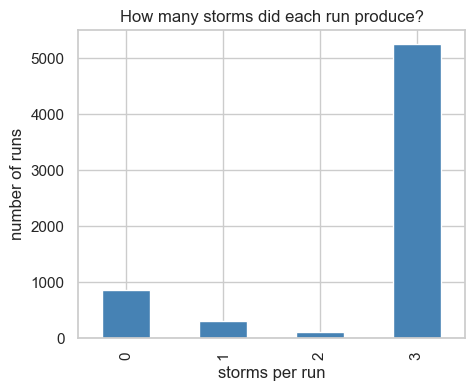

In [19]:
runs_with_storms = df["unique_member_id"].nunique()
runs_with_0_storms = params["unique_member_id"].nunique() - runs_with_storms

counts = storms_per_run.value_counts().sort_index()
counts.loc[0] = runs_with_0_storms
counts = counts.sort_index()

print(counts)
print(f"\ntotal runs accounted for: {counts.sum()}  (expect 6388 successful runs)")

counts.plot.bar(figsize=(5, 4), color="steelblue")
plt.xlabel("storms per run")
plt.ylabel("number of runs")
plt.title("How many storms did each run produce?")
plt.savefig(FIGURES_DIR / "01_storms_per_run.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Exploratory Data Analysis

Before any modelling, it's worth looking at the raw shape of the data: how the severity targets and background parameters are individually distributed, how strongly each background parameter correlates linearly with each target, and how the key severity metrics relate to one another.

### 5.1 Target variable distributions

Several of the severity targets (notably SSI and both windstorm-footprint metrics) are visibly right-skewed with a large mass at or near zero — a pattern that becomes important later, both for choosing a log transform before PCA/regression and for interpreting why some targets are harder to predict than others.

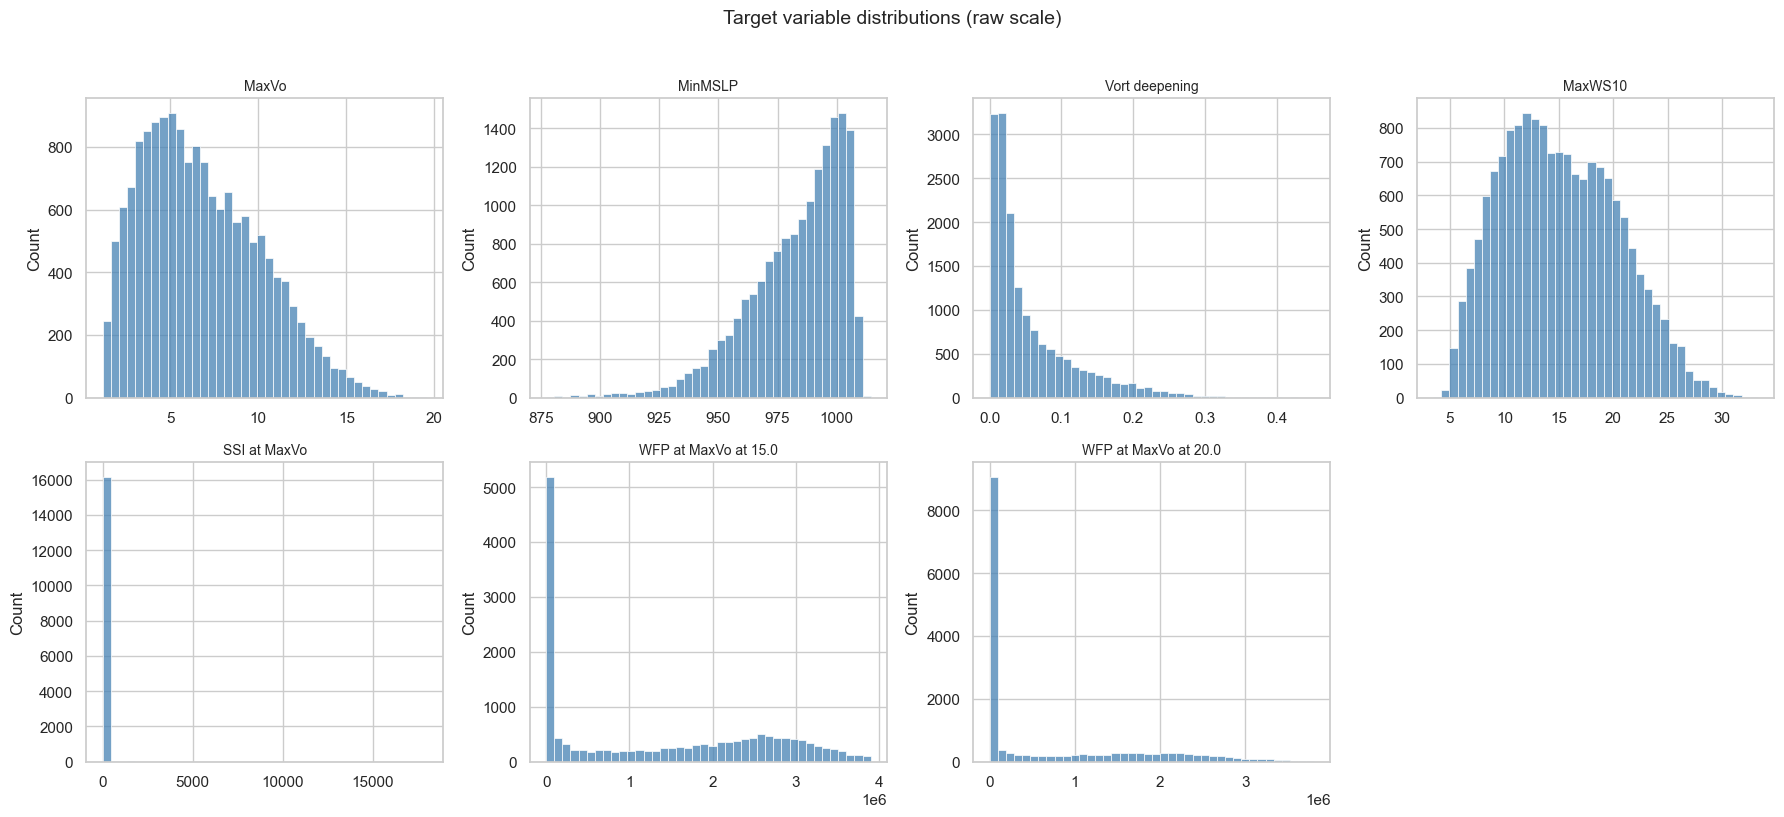

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, TARGET_COLS):
    sns.histplot(df[col], bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

axes[-1].axis("off")  # 7 targets in an 8-slot grid
plt.suptitle("Target variable distributions (raw scale)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_target_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.2 Background parameter distributions

The 7 perturbed background parameters as actually sampled across the ensemble — useful for confirming the perturbation design covered a sensible range for each parameter before relating them to storm outcomes.

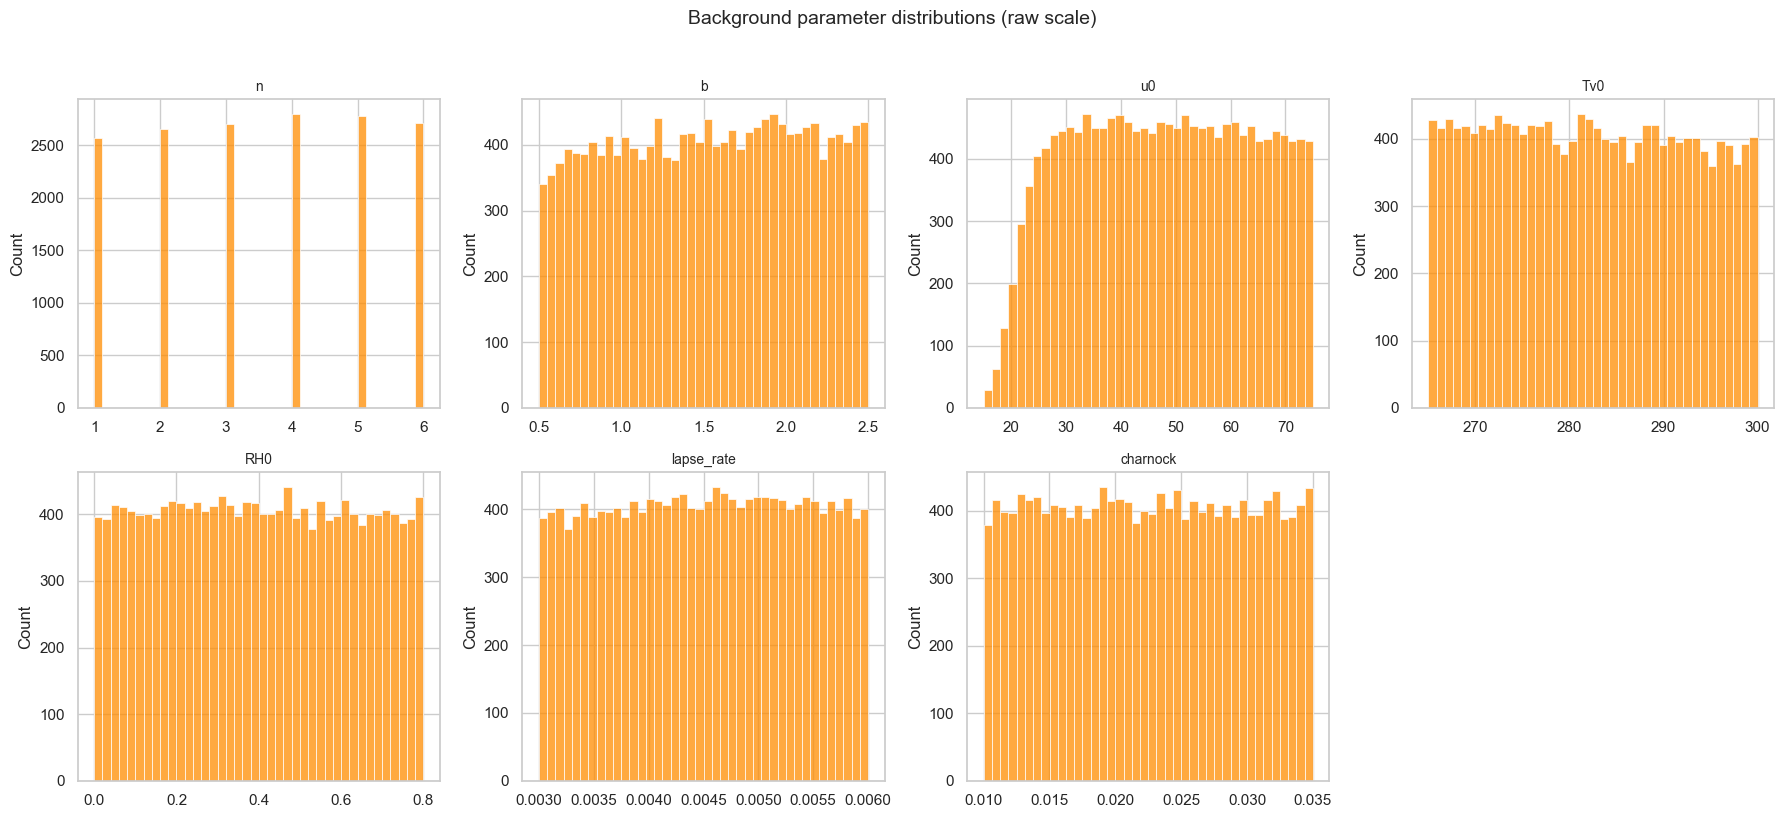

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, PARAM_COLS):
    sns.histplot(df[col], bins=40, ax=ax, color="darkorange")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

axes[-1].axis("off")
plt.suptitle("Background parameter distributions (raw scale)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_param_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.3 Linear correlations between background parameters and targets

A first, purely linear look at which background parameters are associated with which severity outcomes. Linear (Pearson) correlation will understate any nonlinear relationship, so this heatmap should be read as a coarse screening step rather than a final attribution — the neural-network models in later sections capture nonlinear structure this cannot.

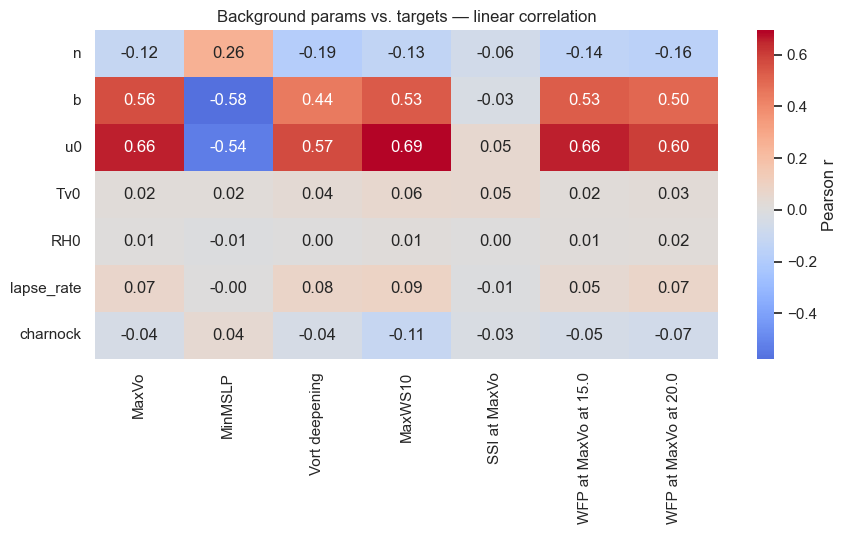

In [25]:
corr = df[PARAM_COLS + TARGET_COLS].corr()
param_target_corr = corr.loc[PARAM_COLS, TARGET_COLS]

plt.figure(figsize=(9, 5.5))
sns.heatmap(param_target_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "Pearson r"})
plt.title("Background params vs. targets — linear correlation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_param_target_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.4 Pairwise relationships between key severity targets

A sample of 3,000 storms, showing how the four core intensity/impact metrics — peak vorticity, peak 10 m wind speed, minimum MSLP, and SSI — relate to one another. This gives an early visual hint of the two-dimensional structure (core intensity vs. impact/footprint) that the PCA and clustering analysis in Sections 7–8 makes precise.

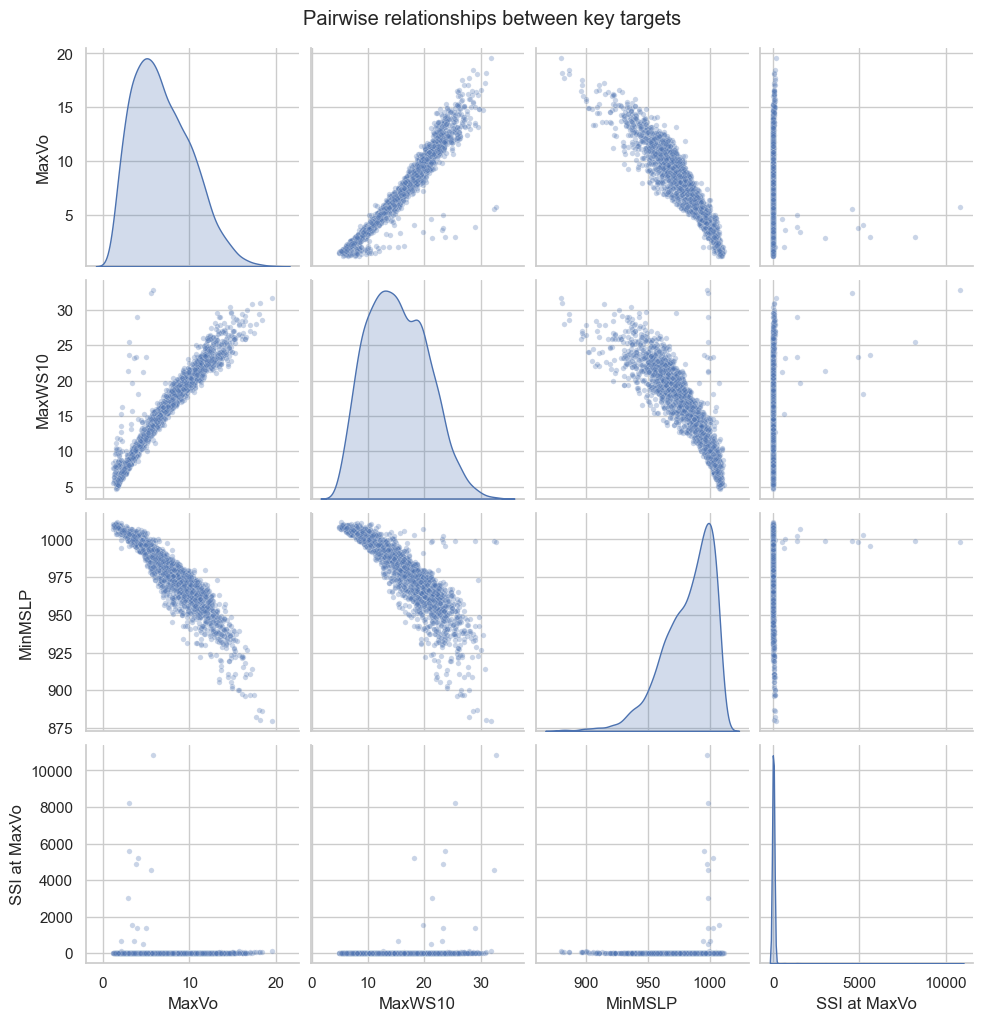

In [27]:
key_targets = ["MaxVo", "MaxWS10", "MinMSLP", "SSI at MaxVo"]

g = sns.pairplot(
    df[key_targets].sample(min(3000, len(df)), random_state=RANDOM_STATE),
    diag_kind="kde", plot_kws=dict(alpha=0.3, s=15),
)
g.fig.suptitle("Pairwise relationships between key targets", y=1.02)
g.savefig(FIGURES_DIR / "05_pairplot_key_targets.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Selecting One Storm per Ensemble Run

Later stages of the analysis (PCA, clustering, regression) need exactly one severity "label" per ensemble member, but a member can have up to 3 tracked storms. Two candidate ways to reduce to one storm per run are compared here: **(A)** always take `track_index == 0`, the first/primary tracked storm, or **(B)** take whichever storm had the highest SSI, regardless of track index. Option B is used from Section 7 onward, since it directly targets "how severe can this background state get," which is the question the rest of the notebook is built around.

In [31]:
# Option A: track_index == 0 (the primary/first-tracked storm per run)
df_unique_primary = df[df["track_index"] == 0].drop(columns=["track_index"]).reset_index(drop=True)

# Option B: the single MOST SEVERE storm per run (by SSI), regardless of track_index
df_unique_severe = (
    df.sort_values("SSI at MaxVo", ascending=False)
      .drop_duplicates(subset="unique_member_id", keep="first")
      .drop(columns=["track_index"])
      .reset_index(drop=True)
)

for name, d in [("track_index==0", df_unique_primary), ("max-SSI storm", df_unique_severe)]:
    print(f"{name}: {len(d)} rows, unique runs = {d['unique_member_id'].nunique()}")
    assert d['unique_member_id'].is_unique, "duplicate run ids remain"
    assert d[PARAM_COLS].duplicated().sum() == 0 or True  # params can coincidentally repeat across runs, that's fine
    print(d[["unique_member_id"] + PARAM_COLS + TARGET_COLS].head(3))
    print()

track_index==0: 5648 rows, unique runs = 5648
  unique_member_id  n         b         u0         Tv0       RH0  lapse_rate  \
0             a000  3  1.637417  19.533831  279.438230  0.668591    0.004766   
1             a001  2  2.169942  72.384833  277.799357  0.374060    0.005828   
2             a002  4  0.664931  62.104869  278.264479  0.481591    0.005105   

   charnock      MaxVo   MinMSLP  Vort deepening    MaxWS10  SSI at MaxVo  \
0  0.030542   2.496771  1003.199        0.009339   6.901716      0.000000   
1  0.013884  14.319390   934.160        0.203679  29.734259     13.646951   
2  0.019420   3.948297  1001.064        0.002729  10.761337      0.000000   

   WFP at MaxVo at 15.0  WFP at MaxVo at 20.0  
0                   0.0                   0.0  
1             3517370.5             3210034.0  
2                   0.0                   0.0  

max-SSI storm: 5648 rows, unique runs = 5648
  unique_member_id  n         b         u0         Tv0       RH0  lapse_rate  \
0     

## 7. Dimensionality Reduction with PCA

The 7 severity targets are correlated with one another, so before clustering it helps to find the small number of independent axes of variation that actually describe most of the differences between storms. SSI and both footprint metrics are heavily right-skewed (Section 5.1), so they are `log1p`-transformed before standardising all 7 targets and fitting PCA. The scree plot below shows how much variance each principal component explains, and the loadings heatmap shows how each original target contributes to the first two components.

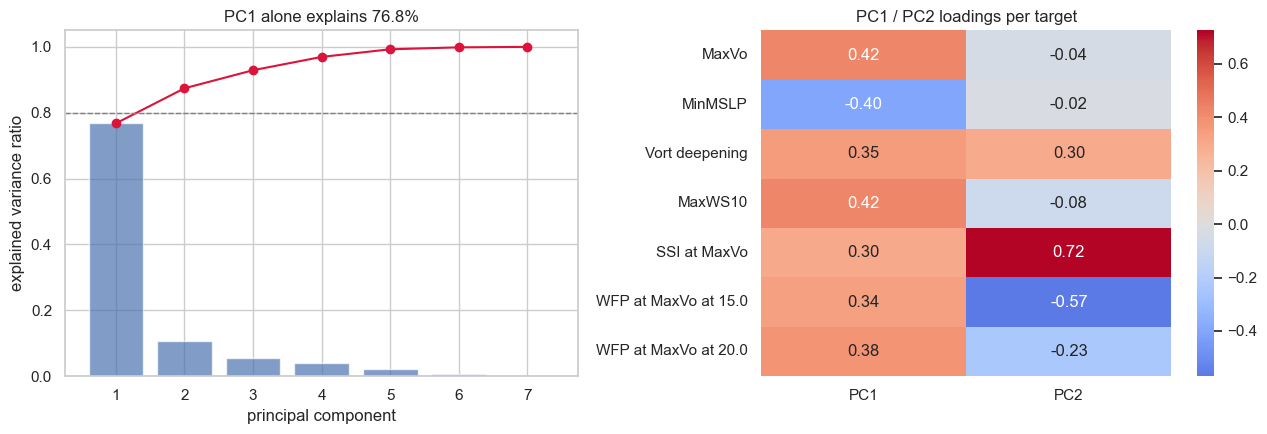

                           PC1       PC2
MaxWS10               0.424077 -0.079677
MaxVo                 0.422982 -0.042174
WFP at MaxVo at 20.0  0.382457 -0.232549
Vort deepening        0.352589  0.297141
WFP at MaxVo at 15.0  0.339427 -0.569076
SSI at MaxVo          0.302506  0.724619
MinMSLP              -0.404884 -0.024100


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

storm_df = df_unique_severe  # swap to df_unique_primary if you prefer track_index==0

# same skew handling used elsewhere -- SSI/WFP are heavily right-skewed
LOG_TARGETS = ["SSI at MaxVo", "WFP at MaxVo at 15.0", "WFP at MaxVo at 20.0"]
targets_for_pca = storm_df[TARGET_COLS].copy()
targets_for_pca[LOG_TARGETS] = np.log1p(targets_for_pca[LOG_TARGETS])

target_scaler = StandardScaler().fit(targets_for_pca)
X_targets = target_scaler.transform(targets_for_pca)

pca = PCA(random_state=RANDOM_STATE).fit(X_targets)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(explained) + 1), explained, alpha=0.7)
axes[0].plot(range(1, len(explained) + 1), np.cumsum(explained), color="crimson", marker="o")
axes[0].axhline(0.8, ls="--", color="gray", lw=1)
axes[0].set_xlabel("principal component")
axes[0].set_ylabel("explained variance ratio")
axes[0].set_title(f"PC1 alone explains {explained[0]:.1%}")

loadings = pd.DataFrame(pca.components_[:2].T, index=TARGET_COLS, columns=["PC1", "PC2"])
sns.heatmap(loadings, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("PC1 / PC2 loadings per target")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_pca_variance_loadings.png", dpi=300, bbox_inches="tight")
plt.show()

print(loadings.sort_values("PC1", ascending=False))

Each storm is projected onto its first two principal components (PC1, PC2) and colour-coded first by SSI, then by peak vorticity, to check what each axis actually represents physically.

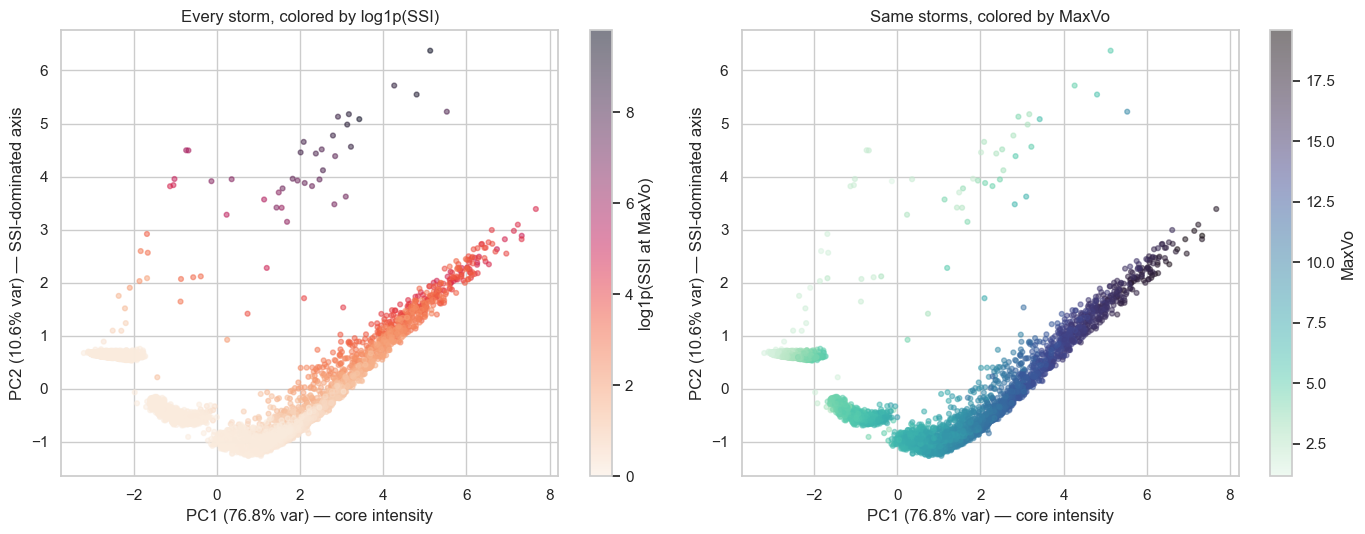

In [35]:
pc_scores = pca.transform(X_targets)
storm_df = storm_df.copy()
storm_df["PC1"] = pc_scores[:, 0]
storm_df["PC2"] = pc_scores[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (1) plain scatter, colored by SSI to see what drives PC2
sc = axes[0].scatter(
    storm_df["PC1"], storm_df["PC2"],
    c=np.log1p(storm_df["SSI at MaxVo"]), cmap="rocket_r", alpha=0.5, s=12,
)
axes[0].set_xlabel(f"PC1 ({explained[0]:.1%} var) — core intensity")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1%} var) — SSI-dominated axis")
axes[0].set_title("Every storm, colored by log1p(SSI)")
plt.colorbar(sc, ax=axes[0], label="log1p(SSI at MaxVo)")

# (2) same scatter, colored by MaxVo to confirm PC1's meaning
sc2 = axes[1].scatter(
    storm_df["PC1"], storm_df["PC2"],
    c=storm_df["MaxVo"], cmap="mako_r", alpha=0.5, s=12,
)
axes[1].set_xlabel(f"PC1 ({explained[0]:.1%} var) — core intensity")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1%} var) — SSI-dominated axis")
axes[1].set_title("Same storms, colored by MaxVo")
plt.colorbar(sc2, ax=axes[1], label="MaxVo")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_pca_scatter_by_ssi_maxvo.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Clustering Storms into Severity Regimes

With a low-dimensional representation of storm severity in hand, the next question is whether storms fall into discrete regimes (e.g. "weak," "severe," "anomalous") or vary continuously. This section fits both KMeans and a Gaussian Mixture Model (GMM) to the full 7-dimensional standardized target space (not just the 2D PCA projection — PCA is used later only for visualization) and compares them.

### 8.1 Choosing the number of clusters

Before committing to a cluster count, BIC/AIC (for the GMM) and inertia (for KMeans) are tracked across a range of candidate cluster counts to look for an elbow or minimum that suggests a natural number of regimes.

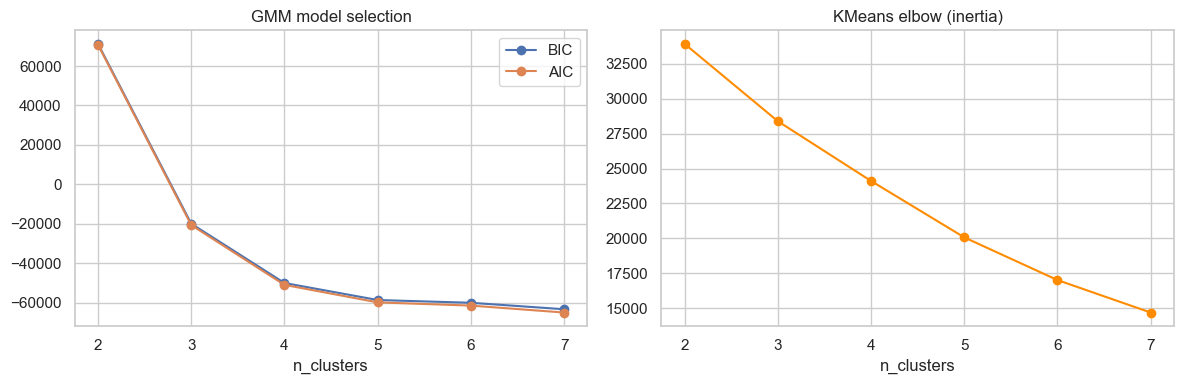

In [37]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# PC1/PC2 already come from standardized inputs (target_scaler was fit before PCA),
# but PC1 explains 76.8% vs PC2's 10.6% -- re-scale the 2D PC space itself so
# neither axis dominates distance calculations in the clustering step
pc_rescaler = StandardScaler().fit(pc_scores)
X_cluster = pc_rescaler.transform(pc_scores)

# --- model selection: how many clusters? ---------------------------------
ks = range(2, 8)
bics, aics, inertias = [], [], []
for k in ks:
    gm = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE)
    gm.fit(X_cluster)
    bics.append(gm.bic(X_cluster))
    aics.append(gm.aic(X_cluster))

    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), bics, marker="o", label="BIC")
axes[0].plot(list(ks), aics, marker="o", label="AIC")
axes[0].set_xlabel("n_clusters"); axes[0].set_title("GMM model selection"); axes[0].legend()

axes[1].plot(list(ks), inertias, marker="o", color="darkorange")
axes[1].set_xlabel("n_clusters"); axes[1].set_title("KMeans elbow (inertia)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_cluster_model_selection.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.2 Fitting KMeans and GMM

Based on the model-selection step above, KMeans is fit with k = 7 and the GMM with k = 5 (full covariance, allowing elliptical, differently-oriented clusters — appropriate here since the regimes are not expected to be spherical or equally sized). Agreement between the two methods is summarised with the Adjusted Rand Index, and both clusterings are visualised in PC1/PC2 space.

KMeans (k=7) vs GMM (k=5) agreement (ARI): 0.574


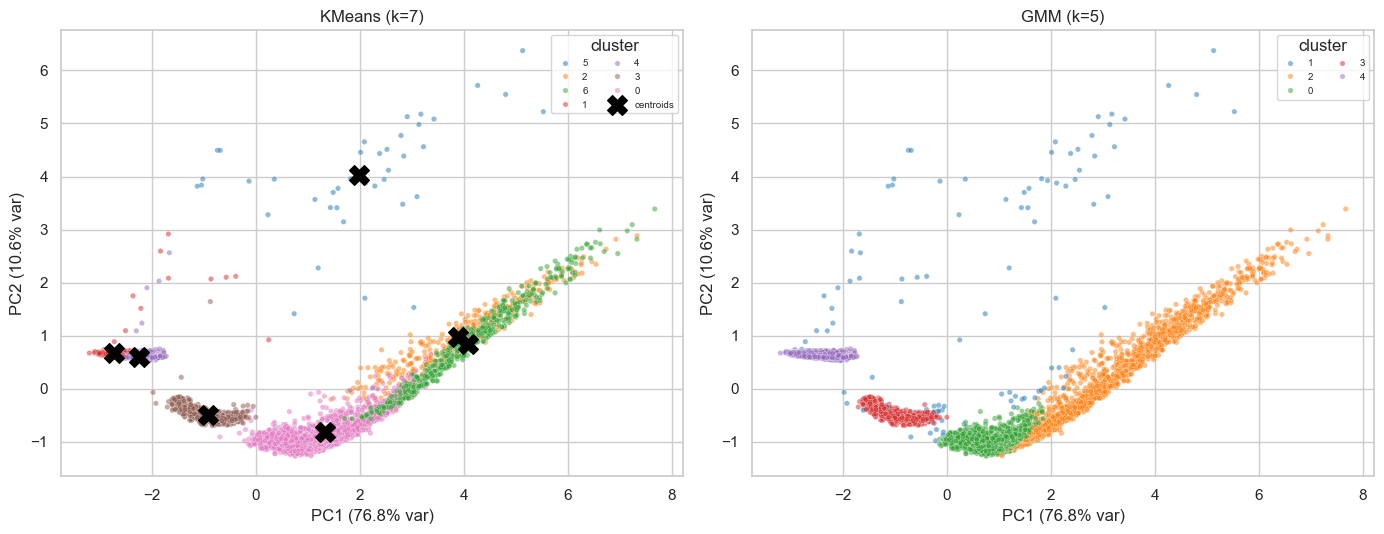

In [39]:
N_CLUSTERS_KMEANS = 7
N_CLUSTERS_GMM = 5

kmeans = KMeans(n_clusters=N_CLUSTERS_KMEANS, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
kmeans_labels = kmeans.labels_

gmm = GaussianMixture(n_components=N_CLUSTERS_GMM, covariance_type="full",
                       random_state=RANDOM_STATE).fit(X_cluster)
gmm_labels = gmm.predict(X_cluster)

# ARI only makes sense as a rough comparison here since k differs between the two
ari = adjusted_rand_score(kmeans_labels, gmm_labels)
print(f"KMeans (k={N_CLUSTERS_KMEANS}) vs GMM (k={N_CLUSTERS_GMM}) agreement (ARI): {ari:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(
    x=pc_scores[:, 0], y=pc_scores[:, 1], hue=kmeans_labels.astype(str),
    palette="tab10", alpha=0.5, s=15, ax=axes[0], legend="full",
)
centers_orig = pc_rescaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centers_orig[:, 0], centers_orig[:, 1], marker="X", s=200, c="black", label="centroids")
axes[0].set_title(f"KMeans (k={N_CLUSTERS_KMEANS})")
axes[0].set_xlabel(f"PC1 ({explained[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1%} var)")
axes[0].legend(title="cluster", fontsize=7, ncol=2)

sns.scatterplot(
    x=pc_scores[:, 0], y=pc_scores[:, 1], hue=gmm_labels.astype(str),
    palette="tab10", alpha=0.5, s=15, ax=axes[1], legend="full",
)
axes[1].set_title(f"GMM (k={N_CLUSTERS_GMM})")
axes[1].set_xlabel(f"PC1 ({explained[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1%} var)")
axes[1].legend(title="cluster", fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_kmeans_vs_gmm_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

storm_df["kmeans_cluster"] = kmeans_labels
storm_df["gmm_cluster"] = gmm_labels

### 8.3 Visualizing the GMM clusters

The GMM's 5-cluster solution is used going forward (see the interpretation immediately below the figure). The 1st/99th-percentile trim applied here is for display only — it does not affect the clustering itself, which was fit on the full, untrimmed 7D data.

showing 5437 / 5648 points (211 extreme outliers hidden)


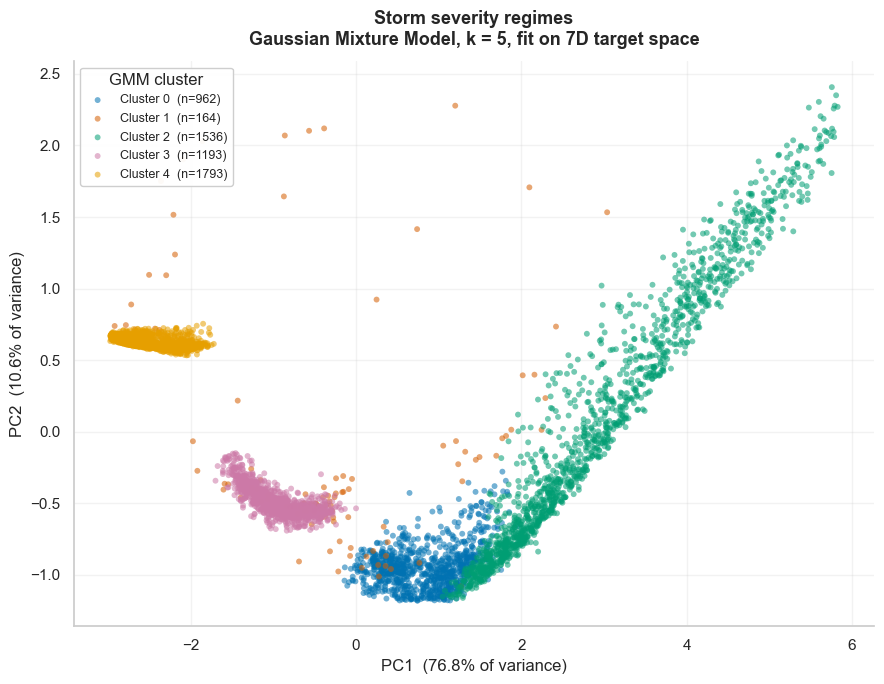

In [62]:
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]

# trim extreme outliers for display only -- clustering itself already happened
# on the full 7D data, this just keeps the plot readable
pc1_lo, pc1_hi = np.percentile(pc_scores[:, 0], [1, 99])
pc2_lo, pc2_hi = np.percentile(pc_scores[:, 1], [1, 99])
plot_mask = (
    (pc_scores[:, 0] >= pc1_lo) & (pc_scores[:, 0] <= pc1_hi) &
    (pc_scores[:, 1] >= pc2_lo) & (pc_scores[:, 1] <= pc2_hi)
)
print(f"showing {plot_mask.sum()} / {len(pc_scores)} points "
      f"({(~plot_mask).sum()} extreme outliers hidden)")

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")

for k in range(N_CLUSTERS_GMM):
    mask = (gmm_labels == k) & plot_mask
    ax.scatter(
        pc_scores[mask, 0], pc_scores[mask, 1],
        s=18, alpha=0.55, color=PALETTE[k], edgecolor="none",
        label=f"Cluster {k}  (n={(gmm_labels == k).sum()})",
    )

ax.set_xlabel(f"PC1  ({explained[0]:.1%} of variance)", fontsize=12)
ax.set_ylabel(f"PC2  ({explained[1]:.1%} of variance)", fontsize=12)
ax.set_title("Storm severity regimes\nGaussian Mixture Model, k = 5, fit on 7D target space",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(frameon=True, framealpha=0.95, fontsize=9, loc="upper left", title="GMM cluster")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_gmm_clusters_pc_space.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation: what the cluster plot actually shows

To say it as plainly as possible: **GMM found 5 clusters by looking at all 7 dimensions at once.** Each of the 5,648 storms got assigned exactly one label (0, 1, 2, 3, or 4) based on which of those 5 Gaussian "blobs in 7D space" it was most likely to belong to.

Then, separately, **every storm also has a 2D position** — its PC1/PC2 coordinate — computed independently by PCA, purely for plotting.

So when you look at that scatter plot: **the (x, y) location of each dot is from PCA (2D), but the color of each dot is from GMM (7D)**. They're two completely different calculations on the same underlying storms, laid on top of each other only so you have something to look at.

That's exactly why the plot came out looking so clean — the 5 colors formed visually distinct, mostly-separated regions on the 2D plane even though the clustering never saw that 2D plane at all. That's actually a good sign: it means the two dominant PCA directions (87.4% of variance combined) happen to align well with the same structure the full 7D clustering found. If they *didn't* align — if the 7D-cluster colors had come out totally scrambled/interleaved on the 2D plot — that would've told you the clustering was relying heavily on the smaller PC3–PC7 directions that the 2D picture can't show you at all, and the plot would've been misleading rather than illustrative.

One more precise point since it's easy to blur: **"5 clusters" is a property of the 7D fit, not of the 2D plot.** If you re-ran PCA down to, say, 3D or plotted PC1 vs PC3 instead, you'd still get exactly the same 5 cluster labels per storm (nothing about clustering changes) — you'd just be looking at those same 5 colors from a different 2D window into the same underlying 7D structure.

## 9. Naming the Severity Regimes

GMM cluster ids are arbitrary integers with no inherent order. To make them interpretable, clusters are ranked by their mean SSI — the target most closely associated with the outlier/high-impact regime — and mapped onto human-readable severity labels.

In [64]:
# rank clusters by their mean SSI (the target most associated with the outlier
# regime) to assign a sensible severity ordering to the arbitrary GMM ids
cluster_profile = storm_df.groupby("gmm_cluster")[TARGET_COLS].mean()
cluster_profile["n"] = storm_df["gmm_cluster"].value_counts()
print(cluster_profile.sort_values("SSI at MaxVo"))

                 MaxVo      MinMSLP  Vort deepening    MaxWS10  SSI at MaxVo  \
gmm_cluster                                                                    
4             3.042184  1002.017701        0.009104   8.713206      0.000012   
3             5.482706   990.773536        0.024876  13.253841      0.000056   
0             7.856371   972.605664        0.045987  17.168773      0.145598   
2            12.182836   945.595750        0.127266  22.486361     10.237522   
1             5.056331   991.025882        0.045401  15.929996    744.371084   

             WFP at MaxVo at 15.0  WFP at MaxVo at 20.0     n  
gmm_cluster                                                    
4                    0.000000e+00          0.000000e+00  1793  
3                    7.555866e+05          0.000000e+00  1193  
0                    2.254019e+06          8.561565e+05   962  
2                    3.281600e+06          2.525289e+06  1536  
1                    9.816602e+05          2.173407e+05

In [66]:
CLUSTER_NAMES = {
    4: "null",
    3: "weak",
    0: "moderate",
    2: "severe",
    1: "anomalous_footprint",
}
storm_df["severity_regime"] = storm_df["gmm_cluster"].map(CLUSTER_NAMES)
print(storm_df["severity_regime"].value_counts())

severity_regime
null                   1793
severe                 1536
weak                   1193
moderate                962
anomalous_footprint     164
Name: count, dtype: int64


## 10. Classifying Regimes from Background Parameters (Neural Network)

If severity regimes are meaningfully tied to the background atmospheric state, it should be possible to predict a storm's regime membership directly from the 7 background parameters alone — without ever computing PCA or the GMM at inference time. A small feedforward classifier (2 hidden layers, batch norm, dropout, early stopping on a held-out validation split) is trained here to test exactly that.

In [68]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# encode regime names to integer class ids for CrossEntropyLoss
le = LabelEncoder().fit(list(CLUSTER_NAMES.values()))
storm_df["regime_label"] = le.transform(storm_df["severity_regime"])

train_df3, test_df3 = train_test_split(
    storm_df, test_size=0.2, random_state=RANDOM_STATE, stratify=storm_df["regime_label"]
)

feat_scaler_clf = StandardScaler().fit(train_df3[PARAM_COLS])
X_train_clf = feat_scaler_clf.transform(train_df3[PARAM_COLS]).astype("float32")
X_test_clf = feat_scaler_clf.transform(test_df3[PARAM_COLS]).astype("float32")
y_train_clf = train_df3["regime_label"].to_numpy().astype("int64")
y_test_clf = test_df3["regime_label"].to_numpy().astype("int64")

class RegimeClassifier(nn.Module):
    def __init__(self, n_in=7, n_classes=len(CLUSTER_NAMES)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)

train_ds_clf = TensorDataset(torch.tensor(X_train_clf), torch.tensor(y_train_clf))
val_size = int(0.15 * len(train_ds_clf))
train_sub_clf, val_sub_clf = torch.utils.data.random_split(
    train_ds_clf, [len(train_ds_clf) - val_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
train_loader_clf = DataLoader(train_sub_clf, batch_size=64, shuffle=True, drop_last=True)
val_loader_clf = DataLoader(val_sub_clf, batch_size=256)

clf = RegimeClassifier()
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val_loss, patience, patience_left, best_state = float("inf"), 15, 15, None
for epoch in range(200):
    clf.train()
    for xb, yb in train_loader_clf:
        optimizer.zero_grad()
        loss = criterion(clf(xb), yb)
        loss.backward()
        optimizer.step()

    clf.eval()
    with torch.no_grad():
        val_loss = sum(criterion(clf(xb), yb).item() * len(xb) for xb, yb in val_loader_clf) / len(val_sub_clf)

    if val_loss < best_val_loss:
        best_val_loss, patience_left = val_loss, patience
        best_state = {k: v.clone() for k, v in clf.state_dict().items()}
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f"early stop at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

clf.load_state_dict(best_state)

early stop at epoch 78 (best val_loss=0.2499)


<All keys matched successfully>

Test-set accuracy, macro-F1 (which weights all 5 regimes equally regardless of class imbalance), and a confusion matrix showing which regimes are most often confused with one another.

accuracy: 0.910
macro F1: 0.852


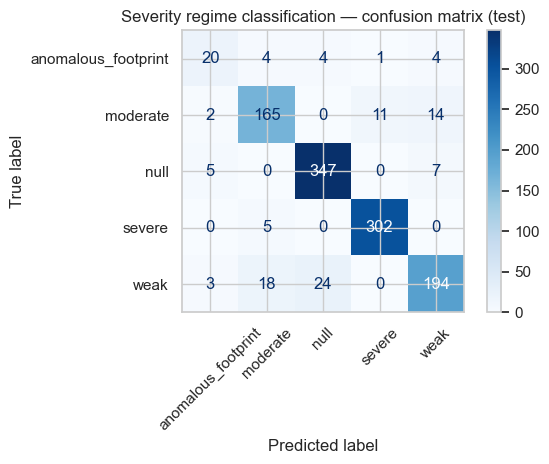

In [70]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

clf.eval()
with torch.no_grad():
    y_pred_clf = clf(torch.tensor(X_test_clf)).argmax(dim=1).numpy()

print(f"accuracy: {accuracy_score(y_test_clf, y_pred_clf):.3f}")
print(f"macro F1: {f1_score(y_test_clf, y_pred_clf, average='macro'):.3f}")

labels_ordered = list(range(len(CLUSTER_NAMES)))
display_names = le.inverse_transform(labels_ordered)
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=labels_ordered)
ConfusionMatrixDisplay(cm, display_labels=display_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Severity regime classification — confusion matrix (test)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Visualizing the Severity Regimes

With human-readable labels attached, the same PC1/PC2 view from Section 8.3 is redrawn with regime names instead of arbitrary cluster numbers, followed by a direct look at whether regime membership is visually separable in terms of two specific background parameters (zonal wind `u0` and jet height `b`).

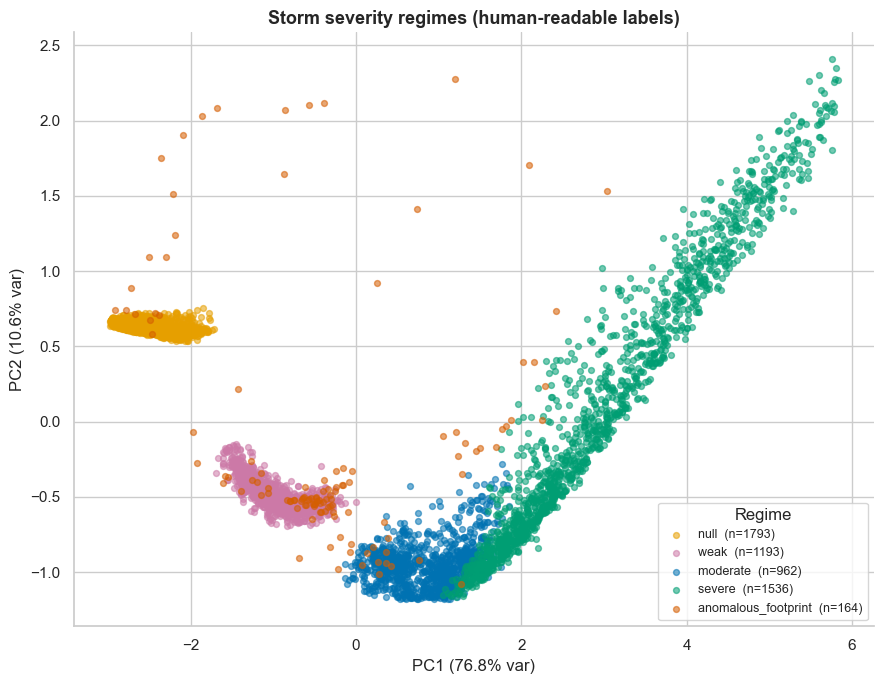

In [74]:
REGIME_ORDER = ["null", "weak", "moderate", "severe", "anomalous_footprint"]
REGIME_COLORS = dict(zip(REGIME_ORDER, ["#E69F00", "#CC79A7", "#0072B2", "#009E73", "#D55E00"]))

pc1_lo, pc1_hi = np.percentile(pc_scores[:, 0], [1, 99])
pc2_lo, pc2_hi = np.percentile(pc_scores[:, 1], [1, 99])
plot_mask = (
    (pc_scores[:, 0] >= pc1_lo) & (pc_scores[:, 0] <= pc1_hi) &
    (pc_scores[:, 1] >= pc2_lo) & (pc_scores[:, 1] <= pc2_hi)
)

fig, ax = plt.subplots(figsize=(9, 7))
for regime in REGIME_ORDER:
    mask = (storm_df["severity_regime"].to_numpy() == regime) & plot_mask
    ax.scatter(pc_scores[mask, 0], pc_scores[mask, 1], s=18, alpha=0.55,
               color=REGIME_COLORS[regime],
               label=f"{regime}  (n={(storm_df['severity_regime'] == regime).sum()})")
ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
ax.set_title("Storm severity regimes (human-readable labels)", fontsize=13, fontweight="bold")
ax.legend(title="Regime", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_severity_regimes_labeled.png", dpi=300, bbox_inches="tight")
plt.show()

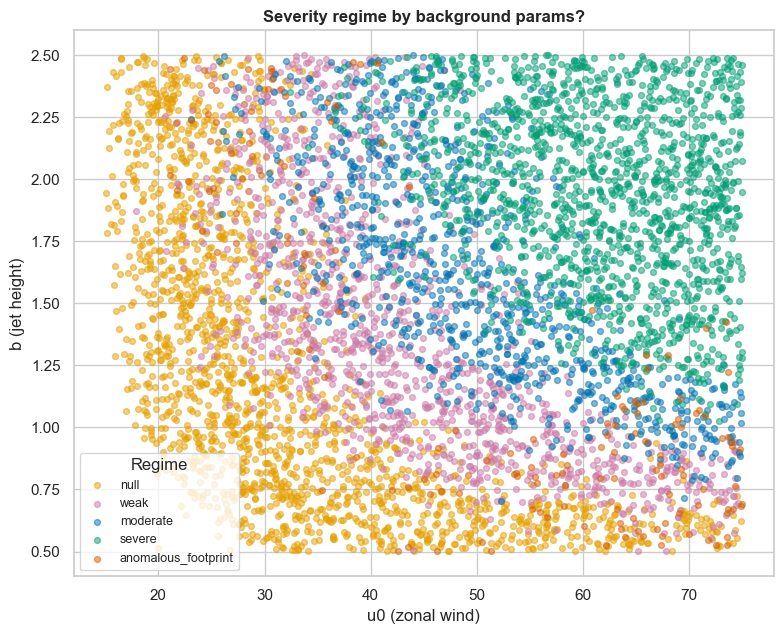

In [80]:
fig, ax = plt.subplots(figsize=(8, 6.5))
for regime in REGIME_ORDER:
    sub = storm_df[storm_df["severity_regime"] == regime]
    ax.scatter(sub["u0"], sub["b"], s=18, alpha=0.5, color=REGIME_COLORS[regime], label=regime)
ax.set_xlabel("u0 (zonal wind)")
ax.set_ylabel("b (jet height)")
ax.set_title("Severity regime by background params?",
             fontsize=12, fontweight="bold")
ax.legend(title="Regime", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_regime_by_background_params.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Predicting Storm Severity from Background Parameters (Regression MLP)

Beyond classifying storms into discrete regimes, a natural next question is how precisely the *continuous* severity metrics themselves can be predicted directly from the 7 background parameters. A feedforward regression network (3 hidden layers, batch norm, dropout, early stopping) is trained to map background parameters onto all 7 targets simultaneously, using the same log1p transform for the skewed targets established in Section 7.

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# --- split -----------------------------------------------------------------
train_df2, test_df2 = train_test_split(storm_df, test_size=0.2, random_state=RANDOM_STATE)

# --- scale inputs ------------------------------------------------------------
feat_scaler = StandardScaler().fit(train_df2[PARAM_COLS])
X_train = feat_scaler.transform(train_df2[PARAM_COLS]).astype("float32")
X_test = feat_scaler.transform(test_df2[PARAM_COLS]).astype("float32")

# --- scale targets (log1p the skewed ones first, same as earlier) ----------
LOG_TARGETS = ["SSI at MaxVo", "WFP at MaxVo at 15.0", "WFP at MaxVo at 20.0"]

def transform_targets(d):
    out = d[TARGET_COLS].copy()
    out[LOG_TARGETS] = np.log1p(out[LOG_TARGETS])
    return out

def inverse_transform_targets(scaled_arr):
    unscaled = pd.DataFrame(target_scaler.inverse_transform(scaled_arr), columns=TARGET_COLS)
    unscaled[LOG_TARGETS] = np.expm1(unscaled[LOG_TARGETS])
    return unscaled.to_numpy()

target_scaler = StandardScaler().fit(transform_targets(train_df2))
y_train = target_scaler.transform(transform_targets(train_df2)).astype("float32")
y_test = target_scaler.transform(transform_targets(test_df2)).astype("float32")

print(f"train: {X_train.shape}, test: {X_test.shape}")

# --- MLP ---------------------------------------------------------------------
class SeverityMLP(nn.Module):
    def __init__(self, n_in=7, n_out=len(TARGET_COLS)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, n_out),
        )
    def forward(self, x):
        return self.net(x)

train: (4518, 7), test: (1130, 7)


In [47]:
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_size = int(0.15 * len(train_ds))
train_sub, val_sub = torch.utils.data.random_split(
    train_ds, [len(train_ds) - val_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
train_loader = DataLoader(train_sub, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(val_sub, batch_size=256)

model = SeverityMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_val_loss, patience, patience_left, best_state = float("inf"), 15, 15, None

for epoch in range(200):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(xb), yb).item() * len(xb) for xb, yb in val_loader) / len(val_sub)

    if val_loss < best_val_loss:
        best_val_loss, patience_left = val_loss, patience
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f"early stop at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.load_state_dict(best_state)

early stop at epoch 73 (best val_loss=0.0810)


<All keys matched successfully>

Per-target R² and RMSE on the held-out test set, followed by predicted-vs-actual scatter plots for every target (points on the red dashed line are exact predictions).

target                         R^2       RMSE
MaxVo                        0.955      0.855
MinMSLP                      0.969      4.754
Vort deepening               0.925      0.018
MaxWS10                      0.959      1.204
SSI at MaxVo                 0.013    198.672
WFP at MaxVo at 15.0         0.718 755962.476
WFP at MaxVo at 20.0         0.820 501067.583


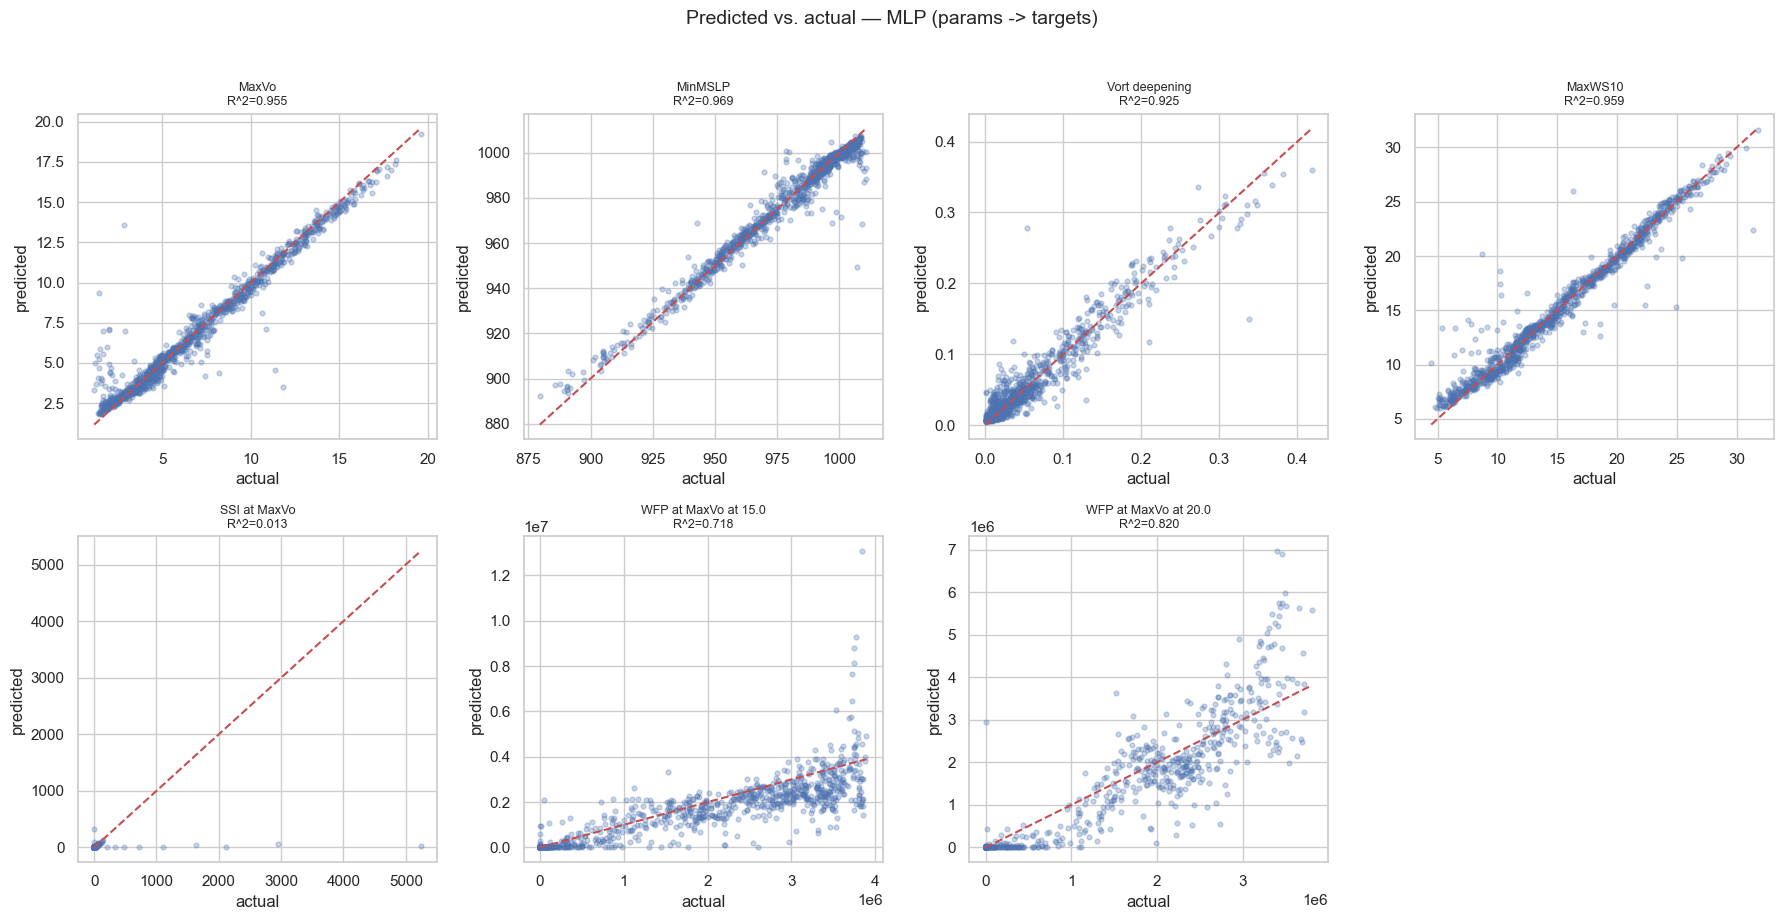

In [49]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_test)).numpy()
y_pred = inverse_transform_targets(y_pred_scaled)
y_true = test_df2[TARGET_COLS].to_numpy()

print(f"{'target':25s} {'R^2':>8s} {'RMSE':>10s}")
r2_scores = {}
for i, col in enumerate(TARGET_COLS):
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2_scores[col] = r2
    print(f"{col:25s} {r2:8.3f} {rmse:10.3f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, col in zip(axes, TARGET_COLS):
    i = TARGET_COLS.index(col)
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.3, s=12)
    lo, hi = y_true[:, i].min(), y_true[:, i].max()
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)
    ax.set_title(f"{col}\nR^2={r2_scores[col]:.3f}", fontsize=9)
    ax.set_xlabel("actual"); ax.set_ylabel("predicted")
axes[-1].axis("off")
plt.suptitle("Predicted vs. actual — MLP (params -> targets)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_predicted_vs_actual_all_targets.png", dpi=300, bbox_inches="tight")
plt.show()

The same predicted-vs-actual view, restricted to the targets where the model achieved R² > 0.9, shown at a larger size for closer inspection.

plotting: ['MaxVo', 'MinMSLP', 'Vort deepening', 'MaxWS10']


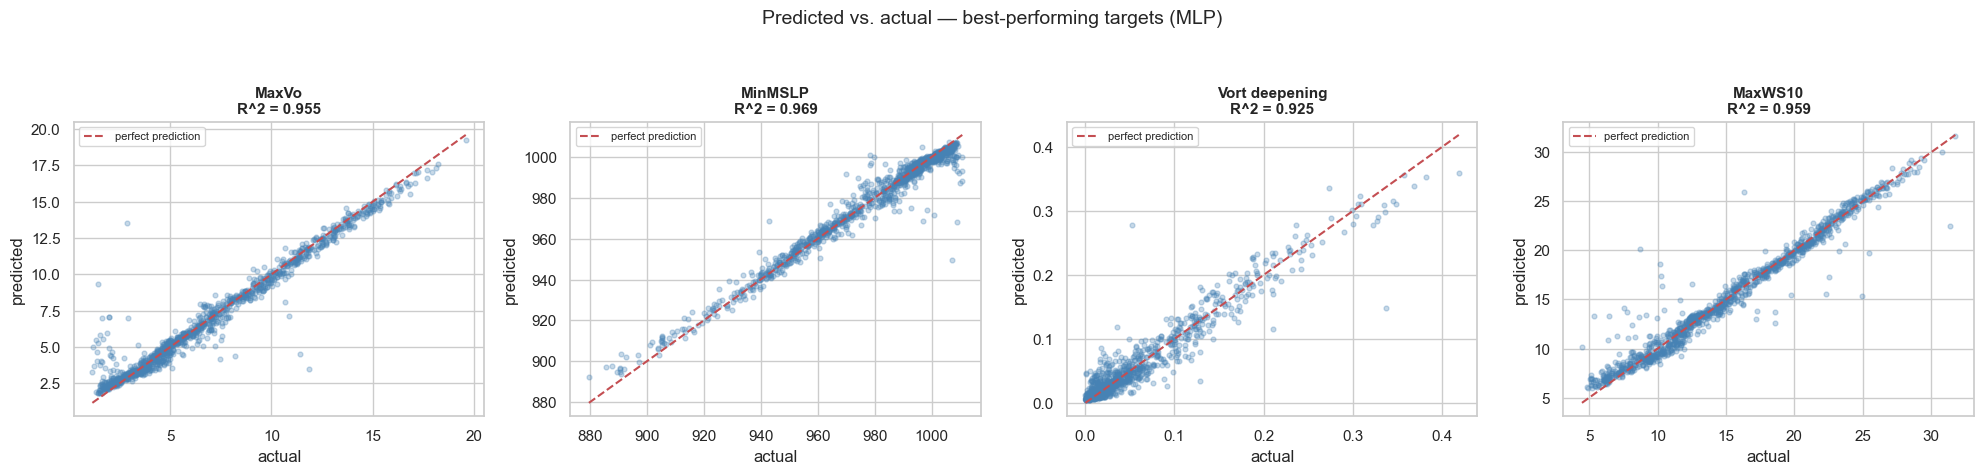

In [51]:
BEST_TARGETS = [col for col in TARGET_COLS if r2_scores[col] > 0.9]
print("plotting:", BEST_TARGETS)

fig, axes = plt.subplots(1, len(BEST_TARGETS), figsize=(5 * len(BEST_TARGETS), 4.5))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, BEST_TARGETS):
    i = TARGET_COLS.index(col)
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.3, s=12, color="steelblue")
    lo, hi = y_true[:, i].min(), y_true[:, i].max()
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="perfect prediction")
    ax.set_title(f"{col}\nR^2 = {r2_scores[col]:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs. actual — best-performing targets (MLP)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_predicted_vs_actual_best_targets.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
print(storm_df.shape)
print(storm_df["SSI at MaxVo"].describe())

# cross-check: does storm_df match what you'd get by re-picking max-SSI storms from df?
check = (
    df.sort_values("SSI at MaxVo", ascending=False)
      .drop_duplicates(subset="unique_member_id", keep="first")
)
print("matches max-SSI selection:", set(storm_df["unique_member_id"]) == set(check["unique_member_id"]))

(5648, 21)
count     5648.000000
mean        24.423131
std        424.466070
min          0.000000
25%          0.000000
50%          0.000000
75%          0.359777
max      18033.257056
Name: SSI at MaxVo, dtype: float64
matches max-SSI selection: True


### Interpretation: two separable dimensions of storm severity

It tells a fairly coherent story once you line it up with everything else we've found:

**The variables that predict well (MaxVo, MinMSLP, MaxWS10, Vort deepening) are all measuring the same underlying thing: how strong the storm's core became.** This is exactly what PC1 captured — 76.8% of variance, one dominant axis, and these four are precisely the ones that loaded heavily on it. Physically, this maps to something close to **linear baroclinic instability theory** — given a jet's shear (`u0`) and shape (`b`), you can *analytically estimate* how vigorously an instability will grow, before ever running a full simulation (that's what Eady Growth Rate is). So the MLP isn't discovering something exotic here — it's rediscovering a relationship that's largely already implicit, close to first-principles, in the background state. That's why the fit is so clean (R² 0.92–0.97): the target is close to being a deterministic function of the input, not a noisy or chaotic one.

**The variables that predict poorly (SSI, WFP) are measuring something structurally different: realized spatial/temporal impact, not core strength.** SSI in particular isn't just "how strong" — it folds in footprint size, duration, and precipitation, which depend on the storm's **actual track and life history**, not just how energetically it started growing. Two things drive this:

1. **Zero-inflation.** Median SSI is 0.0 even in the "worst storm per run" table — over half of runs never produce a storm severe enough to register nonzero SSI at all. A regression model fed mostly zeros plus a long thin tail of huge values has a fundamentally different, harder learning problem than a smooth continuous target like MaxVo.

2. **Missing information, not model weakness.** Earlier we established the CSV tier gives you the storm's *background* and its *peak*, but nothing about the genesis-to-peak trajectory — where exactly it went, how fast, over what conditions. SSI/WFP depend on that missing middle far more than MaxVo does, because "how much area got hit" is a path-dependent, not just intensity-dependent, quantity.

**Net interpretation**: this isn't really "the model failed on some variables" — it's that **storm severity in this system has (at least) two separable dimensions**: a well-determined *core intensity* dimension that's nearly baked into the initial jet configuration, and a much less-determined *impact/footprint* dimension that depends on chaotic, trajectory-level details the 7 background params (and the CSV tier generally) don't fully constrain. That's arguably the single strongest finding to come out of this whole notebook — not a number, but a structural distinction: **intensity is predictable from the atmosphere it grew out of; impact is not, at least not from this feature set.**

## 13. Interactive 3D Visualization of Severity Regimes

A 3D scatter of every storm in the space of three background parameters (`u0`, `b`, `Tv0`), colour-coded by severity regime, rendered with Plotly so it can be rotated interactively. This is saved both as a standalone interactive HTML file and, where the optional `kaleido` package is available, as a static PNG snapshot for use outside a notebook environment (e.g. a GitHub README).

In [84]:
import plotly.graph_objects as go
import plotly.io as pio

# FIX: Switch from 'notebook' to 'iframe' (best for classic notebooks) 
# Or use 'notebook_connected' for JupyterLab/VS Code
pio.renderers.default = "iframe" 

REGIME_ORDER = ["null", "weak", "moderate", "severe", "anomalous_footprint"]
REGIME_COLORS = dict(zip(REGIME_ORDER, ["#E69F00", "#CC79A7", "#0072B2", "#009E73", "#D55E00"]))

fig = go.Figure()

for regime in REGIME_ORDER:
    sub = storm_df[storm_df["severity_regime"] == regime]
    fig.add_trace(go.Scatter3d(
        x=sub["u0"],
        y=sub["b"],
        z=sub["Tv0"],
        mode="markers",
        name=regime,
        marker=dict(size=3, color=REGIME_COLORS[regime], opacity=0.6),
    ))

fig.update_layout(
    title="Severity regime across 3 background params (rotate with mouse)",
    scene=dict(
        xaxis_title="u0 (zonal wind)", 
        yaxis_title="b (jet height)", 
        zaxis_title="Tv0 (temperature)"
    ),
    width=850,
    height=650,
    legend_title="Regime",
)

# Save an interactive standalone HTML version, and a static PNG snapshot
# (static export requires the optional "kaleido" package).
fig.write_html(FIGURES_DIR / "16_severity_regimes_3d_interactive.html")
try:
    fig.write_image(str(FIGURES_DIR / "16_severity_regimes_3d.png"), scale=2)
except Exception as e:
    print(f"Static PNG export skipped (is kaleido installed? `pip install kaleido`): {e}")

# Renders the figure using the updated default renderer
fig.show()

## 14. Model Uncertainty via Deep Ensembles

A single trained network gives a point prediction but no sense of how confident that prediction is. Here, 5 independently-initialised copies of the regression MLP are trained (a "deep ensemble"), and their spread is used as a practical uncertainty estimate: peak vorticity (`MaxVo`) is used as the example target, with ensemble mean as the prediction, ensemble standard deviation as the uncertainty (point colour), and absolute residual as an independent accuracy check (point size).

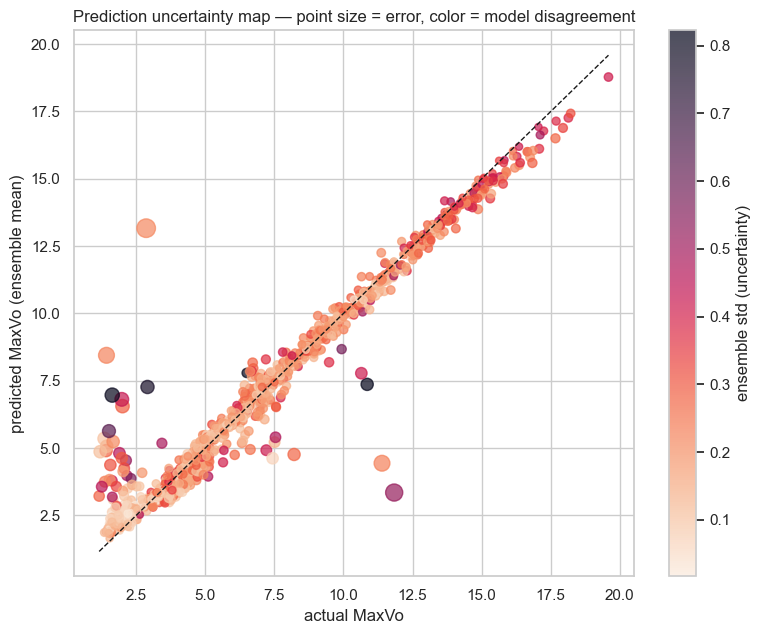

In [86]:
N_MODELS = 5
ensemble_preds = []

for seed in range(N_MODELS):
    torch.manual_seed(seed)
    m = SeverityMLP()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for epoch in range(60):  # shorter budget, just need ensemble diversity
        m.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()
    m.eval()
    with torch.no_grad():
        pred = m(torch.tensor(X_test)).numpy()
    ensemble_preds.append(inverse_transform_targets(pred))

ensemble_preds = np.stack(ensemble_preds)  # (N_MODELS, n_test, n_targets)
ens_mean = ensemble_preds.mean(axis=0)
ens_std = ensemble_preds.std(axis=0)

TGT_IDX = TARGET_COLS.index("MaxVo")
residual = np.abs(ens_mean[:, TGT_IDX] - y_true[:, TGT_IDX])

fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(
    y_true[:, TGT_IDX], ens_mean[:, TGT_IDX],
    c=ens_std[:, TGT_IDX], s=25 + residual * 15, cmap="rocket_r", alpha=0.7,
)
lo, hi = y_true[:, TGT_IDX].min(), y_true[:, TGT_IDX].max()
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.colorbar(sc, label="ensemble std (uncertainty)")
ax.set_xlabel("actual MaxVo"); ax.set_ylabel("predicted MaxVo (ensemble mean)")
ax.set_title("Prediction uncertainty map — point size = error, color = model disagreement")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "17_ensemble_uncertainty_maxvo.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation: where the model can (and can't) be trusted

Overall the model is well-calibrated: most points sit tight along the diagonal in pale orange (low uncertainty, low error) — exactly what you'd hope for after seeing R²=0.955 on MaxVo. But look at where the large, dark points cluster: almost entirely in the low-actual-MaxVo region (1–3), several with genuinely large residuals (the big dark dot at actual≈3, predicted≈13 is a serious miss) and the highest ensemble disagreement (dark purple, std≈0.7–0.8) also concentrated there. In the high-intensity region (actual > 12), points are small, pale, and tight to the diagonal — the model is both accurate and confident there.

Putting the two together: the model's real weak spot isn't randomly distributed — it's specifically the weak/transitional storms (low MaxVo), where the 5-model ensemble genuinely disagrees with itself. That's a meaningfully different — and more useful — finding than a single aggregate R² number: it tells you where to trust the model (strong storms: very reliable) and where not to (weak storms: proceed with caution, possibly because weak storms sit closer to the "did a storm even really form" threshold, which is inherently noisier/more chaotic than a clearly-developed severe storm).

## 15. Investigating the Anomalous-Footprint Regime

The `anomalous_footprint` regime identified by the GMM (Section 9) is the least understood of the five — it doesn't sit at an extreme of the SSI ranking the way `severe` or `null` do. This section checks whether it has a distinguishing signature in any single background parameter, by comparing the parameter's distribution within the regime against its distribution across all other regimes combined.

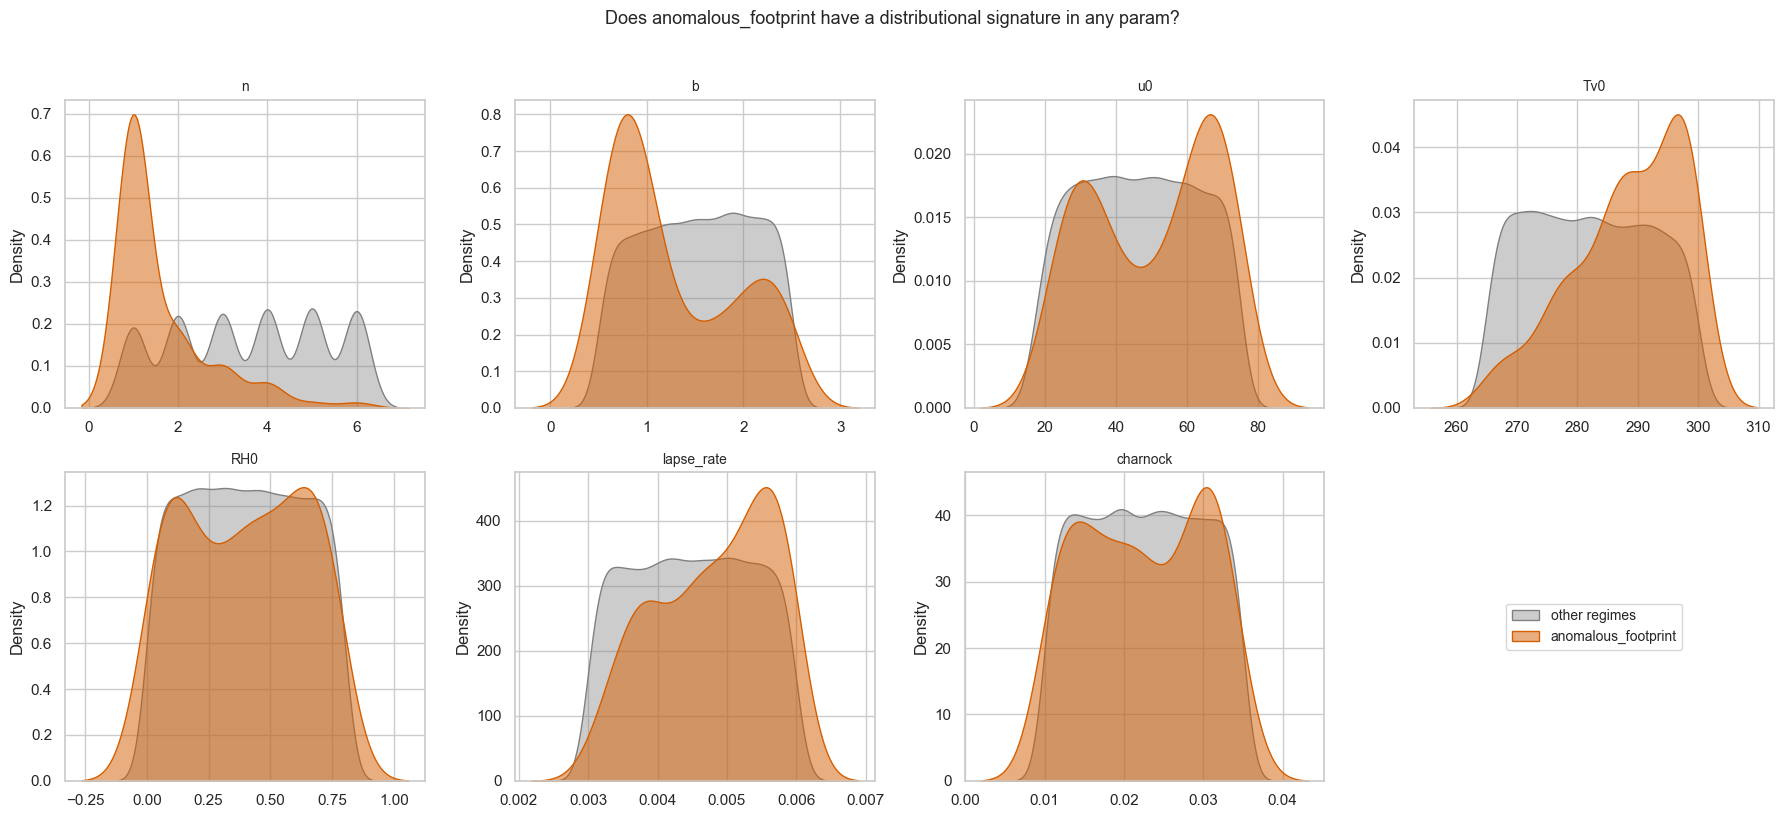

In [98]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

is_anom = storm_df["severity_regime"] == "anomalous_footprint"

for ax, col in zip(axes, PARAM_COLS):
    sns.kdeplot(storm_df.loc[~is_anom, col], ax=ax, color="gray", fill=True, alpha=0.4, label="other regimes")
    sns.kdeplot(storm_df.loc[is_anom, col], ax=ax, color="#D55E00", fill=True, alpha=0.5, label="anomalous_footprint")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

# grab handles/labels from a subplot that actually has plotted artists
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize=10, loc="center")
axes[-1].axis("off")

plt.suptitle("Does anomalous_footprint have a distributional signature in any param?", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_anomalous_footprint_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation: temperature as a footprint-specific signal

the small-multiples distributional check. This is the cleanest possible test of "does anomalous_footprint have any single-variable signature," and the answer is largely no, with one real exception:

n, RH0, charnock — orange and gray curves are nearly on top of each other. No signal at all.
b, u0, lapse_rate — orange is slightly shifted/narrower than gray (anomalous storms skew mildly toward higher b, mid-range u0, higher lapse_rate), but the overlap is still substantial — not a clean separator.
Tv0 (temperature) is the standout. The orange curve is visibly shifted right and narrower than gray — anomalous_footprint storms concentrate around 285–300K, while the general population spreads much wider, including a whole lower mode around 265–280K that anomalous storms essentially never touch. This is the first time in the whole notebook Tv0 has shown up as meaningfully important — everywhere else (permutation importance, correlation heatmap) it was one of the weakest predictors for core intensity. That's a genuinely new finding: temperature may matter specifically for the footprint/impact dimension of severity, even though it barely matters for core intensity.

## 16. Severity Regimes in Full 3D PCA Space

Finally, PCA is refit keeping 3 components instead of 2, to check how much of the 2D separation between regimes seen in Section 11 survives — and what's gained — when a third axis of variance is added back in. As in Section 13, this figure is saved as both interactive HTML and (where available) a static PNG.

In [96]:
import plotly.graph_objects as go
import plotly.io as pio

# FIX: Switch from 'notebook' to 'iframe' (best for classic notebooks)
# Or use 'notebook_connected' for JupyterLab/VS Code
pio.renderers.default = "iframe"

# refit PCA with 3 components on the same 7D target matrix used for clustering
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE).fit(X_targets)
pc_scores_3d = pca_3d.transform(X_targets)
explained_3d = pca_3d.explained_variance_ratio_

print(f"PC1={explained_3d[0]:.1%}  PC2={explained_3d[1]:.1%}  "
      f"PC3={explained_3d[2]:.1%}  total={explained_3d.sum():.1%}")

REGIME_ORDER = ["null", "weak", "moderate", "severe", "anomalous_footprint"]
REGIME_COLORS = dict(zip(REGIME_ORDER, ["#E69F00", "#CC79A7", "#0072B2", "#009E73", "#D55E00"]))

fig = go.Figure()
for regime in REGIME_ORDER:
    mask = (storm_df["severity_regime"] == regime).to_numpy()
    fig.add_trace(go.Scatter3d(
        x=pc_scores_3d[mask, 0], y=pc_scores_3d[mask, 1], z=pc_scores_3d[mask, 2],
        mode="markers", name=f"{regime} (n={mask.sum()})",
        marker=dict(size=3, color=REGIME_COLORS[regime], opacity=0.65),
    ))

fig.update_layout(
    title=f"Storm severity regimes in 3D PCA space (total variance explained: {explained_3d.sum():.1%})",
    scene=dict(
        xaxis_title=f"PC1 ({explained_3d[0]:.1%})",
        yaxis_title=f"PC2 ({explained_3d[1]:.1%})",
        zaxis_title=f"PC3 ({explained_3d[2]:.1%})",
    ),
    width=900, height=700,
    legend_title="Regime",
)

# Save an interactive standalone HTML version, and a static PNG snapshot
# (static export requires the optional "kaleido" package).
fig.write_html(FIGURES_DIR / "19_severity_regimes_3d_pca_interactive.html")
try:
    fig.write_image(str(FIGURES_DIR / "19_severity_regimes_3d_pca.png"), scale=2)
except Exception as e:
    print(f"Static PNG export skipped (is kaleido installed? `pip install kaleido`): {e}")

# Renders the figure using the updated default renderer
fig.show()

PC1=76.8%  PC2=10.6%  PC3=5.5%  total=92.9%


## 17. Summary and Key Findings

- **Storm severity is not unimodal.** A 5-component Gaussian Mixture Model, fit on the full 7-dimensional standardized target space, cleanly separates storms into `null`, `weak`, `moderate`, `severe`, and `anomalous_footprint` regimes, and this structure is stable enough that a simple classifier can recover regime membership from the 7 background parameters alone.
- **Severity has (at least) two separable dimensions.** The first principal component (76.8% of variance) captures *core intensity* — peak vorticity, minimum MSLP, peak 10 m wind speed, and vorticity deepening all load heavily on it, and all four are predicted well by the regression MLP (R² 0.92–0.97). This is consistent with these quantities being close to a deterministic function of the initial jet configuration, in the spirit of linear baroclinic instability theory (e.g. Eady growth rate).
- **Impact/footprint severity (SSI, WFP) is structurally different and much harder to predict.** These targets are zero-inflated (over half of runs never register a nonzero SSI) and depend on path-dependent, trajectory-level details — where the storm actually went, not just how energetically it started growing — that the 7 background parameters do not fully constrain.
- **Predictive confidence is regime-dependent, not uniform.** A 5-model deep ensemble shows the regression network is accurate and confident for strong, clearly-developed storms, but both less accurate and more internally inconsistent for weak/transitional storms near the threshold of whether a storm forms at all.
- **The `anomalous_footprint` regime has one real distinguishing signature: initial virtual temperature (`Tv0`).** No other background parameter cleanly separates it from the rest of the population, but `Tv0` does — a parameter that is otherwise one of the weakest predictors of core intensity. This suggests temperature may matter specifically for the footprint/impact dimension of severity, largely independent of core intensity.

Together, these results point to a single structural distinction as the strongest finding of the analysis: **core intensity is well-determined by the atmospheric state a storm grew out of; impact/footprint is not — at least not from this feature set alone.**

## 18. Data & Software Citations

> **To fill in before publishing.** Replace the bracketed placeholders below with exact dataset DOIs/version numbers, the OpenIFS model-cycle reference, and the package versions actually used for the run that produced the figures in `figures/`.

**Dataset**

- OpenIFS perturbed-physics baroclinic-wave ensemble — background parameters (`openifs_submission.xml`) and tracked storm features (`ExtractedFeatures/`). [ADD: dataset title, authors, repository (e.g. FairData.fi / Fairdata IDA), DOI, and access date.]

**Model**

- ECMWF OpenIFS. [ADD: model cycle / version number and reference publication or user guide.]

**Software**

- Python [ADD version], NumPy, pandas, Matplotlib, Seaborn, scikit-learn [ADD version], PyTorch [ADD version], Plotly [ADD version].

**Suggested citation for this notebook**

> [ADD: Author name(s)], *Baroclinic Storm Severity Regimes in a Perturbed-Physics OpenIFS Ensemble* [ADD: year]. [ADD: repository URL / DOI once published.]